In [ ]:
# =====================================================
# REPLICATION FILE CONTENTS
# =====================================================

# 1. Environment Setup and Package Import
#    - Import required Python libraries
#    - Set working directories and display options

# 2. Raw Data Import
#    - Load Open Data DC benchmarking dataset
#    - Load climate variables (CDD/HDD)
#    - Load auxiliary ownership dataset

# 3. Data Cleaning and Preprocessing
#    - Filter compliant benchmarking records
#    - Remove incomplete and non-informative observations
#    - Handle duplicate/campus structures
#    - Outlier detection and trimming
#    - Property-type recoding and harmonization
#    - Ownership matching using SSL identifiers
#    - Missingness and Energy Star handling

# 4. Variable Construction
#    - Construction of treatment intensity (compliance gap)
#    - Method A: Property-type mean benchmark
#    - Method B: Property-type percentile benchmark
#    - Method C: Citywide benchmark
#    - Post-policy indicators
#    - Interaction terms
#    - Climate control variables (CDD/HDD)

# 5. Descriptive Statistics and Data Visualization
#    - Summary statistics
#    - Distribution plots
#    - Pre/post-policy trends
#    - Figure generation

# 6. Baseline Continuous Difference-in-Differences Estimation
#    - Two-way fixed effects estimation
#    - Continuous treatment specification
#    - Main outcome variables:
#        * Site EUI
#        * Source EUI
#        * Energy Star Score
#        * GHG Emissions
#        * GHG Intensity

# 7. Heterogeneity Analysis
#    - Public vs private ownership
#    - Double interaction models
#    - Triple interaction models

# 8. Dynamic and Event-Study Specifications
#    - Dynamic treatment effects
#    - Event-study estimation
#    - Parallel trends assessment

# 9. Robustness Checks
#    - Alternative benchmark definitions
#    - Alternative post-policy definitions
#    - Donut specification excluding 2020
#    - Alternative treatment intensity measures
#    - Attrition-adjusted models using IPW

# 10. Spatial Dependence and Diagnostic Analysis (if included)
#     - Moran’s I statistics
#     - Spatial diagnostic tests
#     - Alternative spatial weight matrices

# 11. Table Generation
#     - Main regression tables
#     - Robustness tables
#     - Appendix tables

# 12. Figure Generation
#     - Main manuscript figures
#     - Appendix figures
#     - Export procedures

# 13. Export and Replication Outputs
#     - Save cleaned analytical dataset
#     - Export tables and figures
#     - Save model outputs

# =====================================================
# SOFTWARE AND REPRODUCIBILITY NOTES
# =====================================================
# Python version: 3
# Main packages:
# pandas
# numpy
# statsmodels
# linearmodels
# matplotlib
# seaborn (if used)
# scipy
# geopandas (if used)
# pysal/esda/libpysal (if spatial analysis used)

# All results in the manuscript can be reproduced
# by running this script sequentially from top to bottom.
# =====================================================

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import re
import matplotlib.pyplot as plt

In [2]:
beps = pd.read_csv('Building_Energy_Benchmarking.csv')
print(beps)

/var/folders/wz/j37lcf513952clhw4f5gg7v40000gn/T/ipykernel_9052/211582748.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  beps = pd.read_csv('Building_Energy_Benchmarking.csv')


                  X             Y         PID        SSL  PMPROPERTYID  \
0     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
...             ...           ...         ...        ...           ...   
26684 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26685 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26686 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26687 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   
26688 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   

                     PROPERTYNAME PMPARENTPROPERTYID PARENTPROPERTYNAME  \
0               Dahlia Apartments   

# cleaning beps

In [4]:
# Print column names separated by commas
print(", ".join(beps.columns))

X, Y, PID, SSL, PMPROPERTYID, PROPERTYNAME, PMPARENTPROPERTYID, PARENTPROPERTYNAME, REPORTINGYEAR, REPORTSTATUS, ADDRESSOFRECORD, OWNEROFRECORD, WARD, REPORTEDADDRESS, CITY, STATE, POSTALCODE, YEARBUILT, PRIMARYPROPERTYTYPE_SELFSELECT, PRIMARYPROPERTYTYPE_EPACALC, TAXRECORDFLOORAREA, REPORTEDBUILDINGGROSSFLOORAREA, ENERGYSTARSCORE, SITEEUI_KBTU_FT, WEATHERNORMALZEDSITEEUI_KBTUFT, SOURCEEUI_KBTU_FT, WEATHERNORMALZEDSOUREUI_KBTUFT, TOTGHGEMISSIONS_METRICTONSCO2E, TOTGHGEMISSINTENSITY_KGCO2EFT, WATERSCORE_MFPROPERTIES, WATERUSE_ALLWATERSOURCES_KGAL, METEREDAREAS_ENERGY, METEREDAREAS_WATER, NATURALGASUSE_THERMS, FUELOILANDDIESELFUELUSEKBTU, LATITUDE, LONGITUDE, ADDRESSID, XCOORD, YCOORD, GIS_LAST_MOD_DTTM, DISTRCHILLEDWATER_KBTU, DISTRHOTWATER_KBTU, DISTRSTEAM_KBTU, ELECTRICITYUSE_RENEWABLE_KWH, ELECTRICITYUSE_GRID_KWH, NATURALGAS_KBTU_JANUARY, NATURALGAS_KBTU_FEBRUARY, NATURALGAS_KBTU_MARCH, NATURALGAS_KBTU_APRIL, NATURALGAS_KBTU_MAY, NATURALGAS_KBTU_JUNE, NATURALGAS_KBTU_JULY, NATURALGAS

In [5]:
# Replace blank spaces with NaN (if there are any blank strings) and then filter
beps['REPORTEDBUILDINGGROSSFLOORAREA'].replace('', np.nan, inplace=True)

# Drop rows where REPORTEDBUILDINGGROSSFLOORAREA is NaN or zero
beps_a = beps[beps['REPORTEDBUILDINGGROSSFLOORAREA'].notna() & (beps['REPORTEDBUILDINGGROSSFLOORAREA'] != 0)]
print(beps_a)

                  X             Y         PID        SSL  PMPROPERTYID  \
0     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
...             ...           ...         ...        ...           ...   
26684 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26685 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26686 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26687 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   
26688 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   

                     PROPERTYNAME PMPARENTPROPERTYID PARENTPROPERTYNAME  \
0               Dahlia Apartments   

/var/folders/wz/j37lcf513952clhw4f5gg7v40000gn/T/ipykernel_9052/2219161608.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  beps['REPORTEDBUILDINGGROSSFLOORAREA'].replace('', np.nan, inplace=True)


In [6]:
# Count the number of observations per category in the REPORTSTATUS column
reportstatus_counts = beps_a['REPORTSTATUS'].value_counts()

# Display the counts
print(reportstatus_counts)

REPORTSTATUS
In Compliance                17929
Data Under Review by DOEE     3427
Incomplete Report              863
Name: count, dtype: int64


In [7]:
# Drop rows where REPORTSTATUS is 'Data Under Review' or 'Incomplete Report'
beps_a = beps_a[~beps_a['REPORTSTATUS'].isin(['Incomplete Report'])]
beps_a = beps_a[~beps_a['REPORTSTATUS'].isin(['Data Under Review by DOEE'])]
print(beps_a)

                  X             Y         PID        SSL  PMPROPERTYID  \
0     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
...             ...           ...         ...        ...           ...   
26684 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26685 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26686 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26687 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   
26688 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   

                     PROPERTYNAME PMPARENTPROPERTYID PARENTPROPERTYNAME  \
0               Dahlia Apartments   

In [8]:
# Count the number of observations per category in the REPORTSTATUS column
reportstatus_counts = beps_a['REPORTSTATUS'].value_counts()

# Display the counts
print(reportstatus_counts)

REPORTSTATUS
In Compliance    17929
Name: count, dtype: int64


In [9]:
# List of natural gas and electricity columns
natural_gas_columns = [
    'NATURALGAS_KBTU_JANUARY', 'NATURALGAS_KBTU_FEBRUARY', 'NATURALGAS_KBTU_MARCH', 'NATURALGAS_KBTU_APRIL',
    'NATURALGAS_KBTU_MAY', 'NATURALGAS_KBTU_JUNE', 'NATURALGAS_KBTU_JULY', 'NATURALGAS_KBTU_AUGUST',
    'NATURALGAS_KBTU_SEPTEMBER', 'NATURALGAS_KBTU_OCTOBER', 'NATURALGAS_KBTU_NOVEMBER', 'NATURALGAS_KBTU_DECEMBER'
]

electricity_columns = [
    'ELECTRICITYUSE_KBTU_JANUARY', 'ELECTRICITYUSE_KBTU_FEBRUARY', 'ELECTRICITYUSE_KBTU_MARCH', 'ELECTRICITYUSE_KBTU_APRIL',
    'ELECTRICITYUSE_KBTU_MAY', 'ELECTRICITYUSE_KBTU_JUNE', 'ELECTRICITYUSE_KBTU_JULY', 'ELECTRICITYUSE_KBTU_AUGUST',
    'ELECTRICITYUSE_KBTU_SEPTEMBER', 'ELECTRICITYUSE_KBTU_OCTOBER', 'ELECTRICITYUSE_KBTU_NOVEMBER', 'ELECTRICITYUSE_KBTU_DECEMBER'
]

# Calculate total and average for natural gas
beps_a['Total_NaturalGas_KBTU'] = beps_a[natural_gas_columns].sum(axis=1)
beps_a['Average_NaturalGas_KBTU'] = beps_a[natural_gas_columns].mean(axis=1)

# Calculate total and average for electricity
beps_a['Total_Electricity_KBTU'] = beps_a[electricity_columns].sum(axis=1)
beps_a['Average_Electricity_KBTU'] = beps_a[electricity_columns].mean(axis=1)

# Create a new DataFrame by dropping the monthly columns
beps_aggregated = beps_a.drop(columns=natural_gas_columns + electricity_columns)

# Display the new DataFrame
print(beps_aggregated)


                  X             Y         PID        SSL  PMPROPERTYID  \
0     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
...             ...           ...         ...        ...           ...   
26684 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26685 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26686 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26687 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   
26688 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   

                     PROPERTYNAME PMPARENTPROPERTYID PARENTPROPERTYNAME  \
0               Dahlia Apartments   

In [10]:
# Remove rows where PARENTPROPERTYID does not equal PMPROPERTYID or is not "Not Applicable: Standalone Property" or blank
beps_aggregated = beps_aggregated[
    (beps_aggregated['PMPARENTPROPERTYID'] == beps_aggregated['PMPROPERTYID']) |
    (beps_aggregated['PMPARENTPROPERTYID'] == "Not Applicable: Standalone Property") |
    (beps_aggregated['PMPARENTPROPERTYID'].isna()) |
    (beps_aggregated['PMPARENTPROPERTYID'] == "")  
]

# Display the cleaned dataframe
print(beps_aggregated)

                  X             Y         PID        SSL  PMPROPERTYID  \
0     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
...             ...           ...         ...        ...           ...   
26684 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26685 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26686 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
26687 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   
26688 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   

                     PROPERTYNAME PMPARENTPROPERTYID PARENTPROPERTYNAME  \
0               Dahlia Apartments   

In [11]:
# Create a mask that checks for non-zero, non-empty, and non-null values in both columns
mask = (
    beps_aggregated['ELECTRICITYUSE_GRID_KWH'].notna() & 
    beps_aggregated['WEATHERNORMALZEDSITEEUI_KBTUFT'].notna() &
    (beps_aggregated['ELECTRICITYUSE_GRID_KWH'] != 0) &
    (beps_aggregated['WEATHERNORMALZEDSITEEUI_KBTUFT'] != 0) &
    (beps_aggregated['ELECTRICITYUSE_GRID_KWH'] != "") &
    (beps_aggregated['WEATHERNORMALZEDSITEEUI_KBTUFT'] != "")
)

# Filter the DataFrame using the mask
beps_aggregated = beps_aggregated[mask].copy()

# Optionally, reset the index
beps_aggregated.reset_index(drop=True, inplace=True)
print(beps_aggregated)

                  X             Y         PID        SSL  PMPROPERTYID  \
0     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
...             ...           ...         ...        ...           ...   
16874 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
16875 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
16876 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
16877 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   
16878 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   

                     PROPERTYNAME PMPARENTPROPERTYID PARENTPROPERTYNAME  \
0               Dahlia Apartments   

In [12]:
# Create a new column for the natural log of WEATHERNORMALIZEDSITEEUI_KBTUFT, handling non-positive values
beps_aggregated['log_WEATHERNORMALZEDSITEEUI_KBTUFT'] = np.log(beps_aggregated['WEATHERNORMALZEDSITEEUI_KBTUFT'].replace(0, np.nan))

# Calculate the mean and standard deviation of the log-transformed column
mean_log = beps_aggregated['log_WEATHERNORMALZEDSITEEUI_KBTUFT'].mean()
std_log = beps_aggregated['log_WEATHERNORMALZEDSITEEUI_KBTUFT'].std()

# Define the threshold for 2 standard deviations from the mean
lower_bound = mean_log - 2 * std_log
upper_bound = mean_log + 2 * std_log

# Filter the dataframe to remove observations outside of 2 standard deviations
beps_f = beps_aggregated[
    (beps_aggregated['log_WEATHERNORMALZEDSITEEUI_KBTUFT'] >= lower_bound) &
    (beps_aggregated['log_WEATHERNORMALZEDSITEEUI_KBTUFT'] <= upper_bound)
]

# Display the filtered dataframe
print(beps_f)

                  X             Y         PID        SSL  PMPROPERTYID  \
0     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4     -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
...             ...           ...         ...        ...           ...   
16874 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
16875 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
16876 -8.575699e+06  4.711973e+06   PM3633445  2609 0858     3633445.0   
16877 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   
16878 -8.582120e+06  4.709647e+06  PM20248416  1374 0859    20248416.0   

                     PROPERTYNAME PMPARENTPROPERTYID PARENTPROPERTYNAME  \
0               Dahlia Apartments   

In [13]:
# Use .loc to safely assign the new column 'DCZone'
beps_f.loc[:, 'DCZone'] = beps_f['ADDRESSOFRECORD'].str[-2:]

# Display the updated dataframe with the new column
print(beps_f[['ADDRESSOFRECORD', 'DCZone']])


                  ADDRESSOFRECORD DCZone
0          7019 GEORGIA AVENUE NW     NW
1             7019 GEORGIA AVE NW     NW
2             7019 GEORGIA AVE NW     NW
3          7019 GEORGIA AVENUE NW     NW
4             7019 GEORGIA AVE NW     NW
...                           ...    ...
16874             3300 16TH ST NW     NW
16875         3300 16TH STREET NW     NW
16876             3300 16TH ST NW     NW
16877  4755 WHITEHAVEN PARKWAY NW     NW
16878      4835 MACARTHUR BLVD NW     NW

[16059 rows x 2 columns]


/var/folders/wz/j37lcf513952clhw4f5gg7v40000gn/T/ipykernel_9052/2458225864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  beps_f.loc[:, 'DCZone'] = beps_f['ADDRESSOFRECORD'].str[-2:]


In [14]:
# List of columns to drop
columns_to_drop = ['UBID', 'PROPERTYNAME', 'PMPARENTPROPERTYID', 'PARENTPROPERTYNAME', 
                    'OWNEROFRECORD', 'CITY', 'STATE', 'ADDRESSID', 'GIS_LAST_MOD_DTTM', 'OBJECTID',
                   'LASTUPDATE', 'ENFORCEMENT_ACTION', 'VERIFIER_NAME', 'VERIFIER_ORGANIZATION']

# Drop the columns
beps_f = beps_f.drop(columns=columns_to_drop)
print(beps_f.head())

              X             Y         PID        SSL  PMPROPERTYID  \
0 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   

   REPORTINGYEAR   REPORTSTATUS         ADDRESSOFRECORD  WARD  \
0           2019  In Compliance  7019 GEORGIA AVENUE NW   4.0   
1           2020  In Compliance     7019 GEORGIA AVE NW   4.0   
2           2021  In Compliance     7019 GEORGIA AVE NW   4.0   
3           2022  In Compliance  7019 GEORGIA AVENUE NW   4.0   
4           2023  In Compliance     7019 GEORGIA AVE NW   4.0   

       REPORTEDADDRESS  ... DISTRHOTWATER_KBTU  DISTRSTEAM_KBTU  \
0  7019 Georgia Ave NW  ...                0.0              0.0   
1  7019 Georgia Ave NW  ...                0.0        

In [15]:
# Print column names separated by commas
print(", ".join(beps_f.columns))

X, Y, PID, SSL, PMPROPERTYID, REPORTINGYEAR, REPORTSTATUS, ADDRESSOFRECORD, WARD, REPORTEDADDRESS, POSTALCODE, YEARBUILT, PRIMARYPROPERTYTYPE_SELFSELECT, PRIMARYPROPERTYTYPE_EPACALC, TAXRECORDFLOORAREA, REPORTEDBUILDINGGROSSFLOORAREA, ENERGYSTARSCORE, SITEEUI_KBTU_FT, WEATHERNORMALZEDSITEEUI_KBTUFT, SOURCEEUI_KBTU_FT, WEATHERNORMALZEDSOUREUI_KBTUFT, TOTGHGEMISSIONS_METRICTONSCO2E, TOTGHGEMISSINTENSITY_KGCO2EFT, WATERSCORE_MFPROPERTIES, WATERUSE_ALLWATERSOURCES_KGAL, METEREDAREAS_ENERGY, METEREDAREAS_WATER, NATURALGASUSE_THERMS, FUELOILANDDIESELFUELUSEKBTU, LATITUDE, LONGITUDE, XCOORD, YCOORD, DISTRCHILLEDWATER_KBTU, DISTRHOTWATER_KBTU, DISTRSTEAM_KBTU, ELECTRICITYUSE_RENEWABLE_KWH, ELECTRICITYUSE_GRID_KWH, Total_NaturalGas_KBTU, Average_NaturalGas_KBTU, Total_Electricity_KBTU, Average_Electricity_KBTU, log_WEATHERNORMALZEDSITEEUI_KBTUFT, DCZone


In [16]:
# Renaming columns with shorter names
beps_f = beps_f.rename(columns={
    'PRIMARYPROPERTYTYPE_SELFSELECT': 'PropType_SelfSelect',
    'PRIMARYPROPERTYTYPE_EPACALC': 'PropType_EPACalc',
    'TAXRECORDFLOORAREA': 'TaxFloorArea',
    'REPORTEDBUILDINGGROSSFLOORAREA': 'ReportedFloorArea',
    'ENERGYSTARSCORE': 'EnergyStar',
    'SITEEUI_KBTU_FT': 'SiteEUI',
    'WEATHERNORMALZEDSITEEUI_KBTUFT': 'WeatherNormSiteEUI',
    'SOURCEEUI_KBTU_FT': 'SourceEUI',
    'WEATHERNORMALZEDSOUREUI_KBTUFT': 'WeatherNormSourceEUI',
    'TOTGHGEMISSIONS_METRICTONSCO2E': 'GHGEmissions_MetricTons',
    'TOTGHGEMISSINTENSITY_KGCO2EFT': 'GHGIntensity_KgCO2Ft',
    'WATERUSE_ALLWATERSOURCES_KGAL': 'WaterUse_KGAL',
    'NATURALGASUSE_THERMS': 'NatGasUse_Therms',
    'FUELOILANDDIESELFUELUSEKBTU': 'FuelOilDiesel_KBTU',
    'DISTRCHILLEDWATER_KBTU': 'DistChilledWater_KBTU',
    'DISTRHOTWATER_KBTU': 'DistHotWater_KBTU',
    'DISTRSTEAM_KBTU': 'DistSteam_KBTU',
    'ELECTRICITYUSE_RENEWABLE_KWH': 'ElecRenewable_KWH',
    'ELECTRICITYUSE_GRID_KWH': 'ElecGrid_KWH'
})

# Display the updated column names
print(beps_f.columns)

Index(['X', 'Y', 'PID', 'SSL', 'PMPROPERTYID', 'REPORTINGYEAR', 'REPORTSTATUS',
       'ADDRESSOFRECORD', 'WARD', 'REPORTEDADDRESS', 'POSTALCODE', 'YEARBUILT',
       'PropType_SelfSelect', 'PropType_EPACalc', 'TaxFloorArea',
       'ReportedFloorArea', 'EnergyStar', 'SiteEUI', 'WeatherNormSiteEUI',
       'SourceEUI', 'WeatherNormSourceEUI', 'GHGEmissions_MetricTons',
       'GHGIntensity_KgCO2Ft', 'WATERSCORE_MFPROPERTIES', 'WaterUse_KGAL',
       'METEREDAREAS_ENERGY', 'METEREDAREAS_WATER', 'NatGasUse_Therms',
       'FuelOilDiesel_KBTU', 'LATITUDE', 'LONGITUDE', 'XCOORD', 'YCOORD',
       'DistChilledWater_KBTU', 'DistHotWater_KBTU', 'DistSteam_KBTU',
       'ElecRenewable_KWH', 'ElecGrid_KWH', 'Total_NaturalGas_KBTU',
       'Average_NaturalGas_KBTU', 'Total_Electricity_KBTU',
       'Average_Electricity_KBTU', 'log_WEATHERNORMALZEDSITEEUI_KBTUFT',
       'DCZone'],
      dtype='object')


In [17]:
# Print column names separated by commas
print(", ".join(beps_f.columns))

X, Y, PID, SSL, PMPROPERTYID, REPORTINGYEAR, REPORTSTATUS, ADDRESSOFRECORD, WARD, REPORTEDADDRESS, POSTALCODE, YEARBUILT, PropType_SelfSelect, PropType_EPACalc, TaxFloorArea, ReportedFloorArea, EnergyStar, SiteEUI, WeatherNormSiteEUI, SourceEUI, WeatherNormSourceEUI, GHGEmissions_MetricTons, GHGIntensity_KgCO2Ft, WATERSCORE_MFPROPERTIES, WaterUse_KGAL, METEREDAREAS_ENERGY, METEREDAREAS_WATER, NatGasUse_Therms, FuelOilDiesel_KBTU, LATITUDE, LONGITUDE, XCOORD, YCOORD, DistChilledWater_KBTU, DistHotWater_KBTU, DistSteam_KBTU, ElecRenewable_KWH, ElecGrid_KWH, Total_NaturalGas_KBTU, Average_NaturalGas_KBTU, Total_Electricity_KBTU, Average_Electricity_KBTU, log_WEATHERNORMALZEDSITEEUI_KBTUFT, DCZone


In [18]:
# Count missing values (NaN) for each column
missing_values_per_column = beps_f.isnull().sum()

# Display the result
print(missing_values_per_column)


X                                         0
Y                                         0
PID                                       0
SSL                                       0
PMPROPERTYID                              0
REPORTINGYEAR                             0
REPORTSTATUS                              0
ADDRESSOFRECORD                           2
WARD                                     69
REPORTEDADDRESS                           0
POSTALCODE                             1142
YEARBUILT                               322
PropType_SelfSelect                       0
PropType_EPACalc                          2
TaxFloorArea                              0
ReportedFloorArea                         0
EnergyStar                             2031
SiteEUI                                   0
WeatherNormSiteEUI                        0
SourceEUI                                 0
WeatherNormSourceEUI                      0
GHGEmissions_MetricTons                   0
GHGIntensity_KgCO2Ft            

In [19]:
# Print the unique values in the 'PRIMARYPROPERTYTYPE_EPACALC' column
unique_property_types = beps_f['PropType_EPACalc'].unique()

# Display the unique names
print(unique_property_types)

['Multifamily Housing' 'Office' 'K-12 School' 'Hotel' 'Police Station'
 'Fire Station' 'Other - Lodging/Residential' 'Residence Hall/Dormitory'
 'Retail Store' 'College/University' 'Social/Meeting Hall'
 'Supermarket/Grocery Store'
 'Repair Services (Vehicle, Shoe, Locksmith, etc)'
 'Fitness Center/Health Club/Gym' 'Non-Refrigerated Warehouse'
 'Worship Facility' 'Mixed Use Property' 'Retail' 'Parking'
 'Enclosed Mall' 'Senior Living Community' 'Medical Office'
 'Adult Education' 'Strip Mall' 'Other - Public Services' 'Stadium (Open)'
 'Manufacturing/Industrial Plant' 'Wholesale Club/Supercenter'
 'Other - Entertainment/Public Assembly' 'Other - Specialty Hospital'
 'Other/Specialty Hospital' 'Veterinary Office' 'Other' 'Library'
 'Self-Storage Facility' 'Museum' 'Financial Office' nan
 'Prison/Incarceration' 'Convention Center'
 'Urgent Care/Clinic/Other Outpatient'
 'Hospital (General Medical & Surgical)' 'Senior Care Community'
 'Other - Education' 'College/University (Campus-Level)

In [20]:
# Count the number of observations for each unique value in 'PRIMARYPROPERTYTYPE_EPACALC'
property_type_counts = beps_f['PropType_EPACalc'].value_counts()

# Display the counts for each unique property type
print(property_type_counts)

PropType_EPACalc
Multifamily Housing    6787
Office                 5299
Hotel                   961
K-12 School             729
Worship Facility        221
                       ... 
Data Center               1
Other - Mall              1
Veterinary Office         1
Other - Recreation        1
Bar/Nightclub             1
Name: count, Length: 71, dtype: int64


In [21]:
# Collapse all categories with "Other" (case-insensitive) + NaN into "Others"
beps_f['PropType_EPACalc_Collapsed'] = beps_f['PropType_EPACalc'].astype(str)

mask = (
    beps_f['PropType_EPACalc_Collapsed'].str.contains("Other", case=False, na=False)
    | beps_f['PropType_EPACalc'].isna()
)

beps_f.loc[mask, 'PropType_EPACalc_Collapsed'] = "Others"

# Check the new unique values
print(beps_f['PropType_EPACalc_Collapsed'].unique())

['Multifamily Housing' 'Office' 'K-12 School' 'Hotel' 'Police Station'
 'Fire Station' 'Others' 'Residence Hall/Dormitory' 'Retail Store'
 'College/University' 'Social/Meeting Hall' 'Supermarket/Grocery Store'
 'Repair Services (Vehicle, Shoe, Locksmith, etc)'
 'Fitness Center/Health Club/Gym' 'Non-Refrigerated Warehouse'
 'Worship Facility' 'Mixed Use Property' 'Retail' 'Parking'
 'Enclosed Mall' 'Senior Living Community' 'Medical Office'
 'Adult Education' 'Strip Mall' 'Stadium (Open)'
 'Manufacturing/Industrial Plant' 'Wholesale Club/Supercenter'
 'Veterinary Office' 'Library' 'Self-Storage Facility' 'Museum'
 'Financial Office' 'Prison/Incarceration' 'Convention Center'
 'Hospital (General Medical & Surgical)' 'Senior Care Community'
 'College/University (Campus-Level)' 'Performing Arts'
 'Distribution Center' 'Bar/Nightclub' 'Food Service'
 'Refrigerated Warehouse' 'Data Center' 'Recreation'
 'Outpatient Rehabilitation/Physical Therapy'
 'Service (Vehicle Repair/Service, Postal Se

In [22]:
# Count the number of observations for each unique value in 'PRIMARYPROPERTYTYPE_EPACALC'
property_type_counts = beps_f['PropType_EPACalc_Collapsed'].value_counts()

# Display the counts for each unique property type
print(property_type_counts)

PropType_EPACalc_Collapsed
Multifamily Housing                                 6787
Office                                              5299
Hotel                                                961
K-12 School                                          729
Others                                               287
Worship Facility                                     221
Mixed Use Property                                   220
Residence Hall/Dormitory                             199
College/University                                   157
Non-Refrigerated Warehouse                           128
Medical Office                                       118
Fitness Center/Health Club/Gym                        93
Fire Station                                          77
Social/Meeting Hall                                   63
Library                                               62
Retail Store                                          61
Strip Mall                                            47
Poli

In [23]:
# Define mapping from Category 2 -> Category 1
mapping = {
    "Food Sales": "Supermarket/Grocery Store",
    "Outpatient Rehabilitation/Physical Therapy": "Medical Office",
    "Stadium (Open)": "Indoor Arena",
    "Service (Vehicle Repair/Service, Postal Service)": "Repair Services (Vehicle, Shoe, Locksmith, etc)",
    "Repair Services (Vehicle, Shoe, Locksmith, etc.)": "Repair Services (Vehicle, Shoe, Locksmith, etc)",
    "Warehouse (Unrefrigerated)": "Non-Refrigerated Warehouse",
    "Retail": "Retail Store",
    "Vocational School": "Adult Education",
    "Recreation": "Fitness Center/Health Club/Gym", 
    "Vehicle Repair Services": "Repair Services (Vehicle, Shoe, Locksmith, etc)",
    "Bank/Financial Institution": "Financial Office",
    "Data Center": "Others",
    "Bar/Nightclub": "Others",
    "Veterinary Office": "Others"
}

# Apply mapping
beps_f["PropType_EPACalc_Collapsed"] = (
    beps_f["PropType_EPACalc_Collapsed"]
    .replace(mapping)
)

In [24]:
# Count the number of observations for each unique value in 'PRIMARYPROPERTYTYPE_EPACALC'
property_type_counts = beps_f['PropType_EPACalc_Collapsed'].value_counts()

# Display the counts for each unique property type
print(property_type_counts)

PropType_EPACalc_Collapsed
Multifamily Housing                                6787
Office                                             5299
Hotel                                               961
K-12 School                                         729
Others                                              290
Worship Facility                                    221
Mixed Use Property                                  220
Residence Hall/Dormitory                            199
College/University                                  157
Non-Refrigerated Warehouse                          130
Medical Office                                      121
Fitness Center/Health Club/Gym                       94
Fire Station                                         77
Retail Store                                         63
Social/Meeting Hall                                  63
Library                                              62
Strip Mall                                           47
Senior Living Communi

In [25]:
# Count missing values (NaN) for each column
missing_values_per_column = beps_f.isnull().sum()

# Display the result
print(missing_values_per_column)

X                                         0
Y                                         0
PID                                       0
SSL                                       0
PMPROPERTYID                              0
REPORTINGYEAR                             0
REPORTSTATUS                              0
ADDRESSOFRECORD                           2
WARD                                     69
REPORTEDADDRESS                           0
POSTALCODE                             1142
YEARBUILT                               322
PropType_SelfSelect                       0
PropType_EPACalc                          2
TaxFloorArea                              0
ReportedFloorArea                         0
EnergyStar                             2031
SiteEUI                                   0
WeatherNormSiteEUI                        0
SourceEUI                                 0
WeatherNormSourceEUI                      0
GHGEmissions_MetricTons                   0
GHGIntensity_KgCO2Ft            

In [26]:
# Identify columns that contain negative values or strings in the beps_f dataframe
# Checking for columns with negative values
columns_with_negative_values = [col for col in beps_f.select_dtypes(include=['number']).columns if (beps_f[col] < 0).any()]

# Print the columns separated by a comma
print(', '.join(columns_with_negative_values))

X, Y, LATITUDE, LONGITUDE, YCOORD, DistChilledWater_KBTU, DistSteam_KBTU


In [27]:
# Checking for columns with strings
# Checking for columns that contain strings (object type or categorical)
columns_with_strings = beps_f.select_dtypes(include=['object', 'category']).columns.tolist()

# Print the columns separated by a comma
print(', '.join(columns_with_strings))

PID, SSL, REPORTSTATUS, ADDRESSOFRECORD, REPORTEDADDRESS, POSTALCODE, PropType_SelfSelect, PropType_EPACalc, METEREDAREAS_ENERGY, DCZone, PropType_EPACalc_Collapsed


In [28]:
# Checking for columns with positive values only
columns_with_positive_values = [col for col in beps_f.select_dtypes(include=['number']).columns if (beps_f[col] > 0).all()]

# Print the columns separated by a comma
print(', '.join(columns_with_positive_values))


PMPROPERTYID, REPORTINGYEAR, ReportedFloorArea, SiteEUI, WeatherNormSiteEUI, SourceEUI, WeatherNormSourceEUI, XCOORD, ElecGrid_KWH, log_WEATHERNORMALZEDSITEEUI_KBTUFT


In [41]:
# Further Cleaning

In [42]:
beps_f2 = beps_f.copy()
print(beps_f2.head())

              X             Y         PID        SSL  PMPROPERTYID  \
0 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
1 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
2 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
3 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   
4 -8.574542e+06  4.718165e+06  PM14836703  2967 0051    14836703.0   

   REPORTINGYEAR   REPORTSTATUS         ADDRESSOFRECORD  WARD  \
0           2019  In Compliance  7019 GEORGIA AVENUE NW   4.0   
1           2020  In Compliance     7019 GEORGIA AVE NW   4.0   
2           2021  In Compliance     7019 GEORGIA AVE NW   4.0   
3           2022  In Compliance  7019 GEORGIA AVENUE NW   4.0   
4           2023  In Compliance     7019 GEORGIA AVE NW   4.0   

       REPORTEDADDRESS  ... DistSteam_KBTU  ElecRenewable_KWH ElecGrid_KWH  \
0  7019 Georgia Ave NW  ...            0.0                0.0     303833.0   
1  7019 Georgia Ave NW  ...     

In [45]:
# Identify columns that contain negative values or strings in the beps_f dataframe
# Checking for columns with negative values
columns_with_negative_values = [col for col in beps_f2.select_dtypes(include=['number']).columns if (beps_f2[col] < 0).any()]

# Print the columns separated by a comma
print(', '.join(columns_with_negative_values))


X, Y, LATITUDE, LONGITUDE, YCOORD, DistChilledWater_KBTU, DistSteam_KBTU


In [48]:
# Checking for columns with positive values only
columns_with_positive_values = [col for col in beps_f2.select_dtypes(include=['number']).columns if (beps_f2[col] > 0).all()]

# Print the columns separated by a comma
print(', '.join(columns_with_positive_values))


PMPROPERTYID, REPORTINGYEAR, ReportedFloorArea, SiteEUI, WeatherNormSiteEUI, SourceEUI, WeatherNormSourceEUI, XCOORD, ElecGrid_KWH, log_WEATHERNORMALZEDSITEEUI_KBTUFT


In [59]:
# Count missing values (NaN) for each column
missing_values_per_column = beps_f2.isnull().sum()

# Display the result
print(missing_values_per_column)


X                                         0
Y                                         0
PID                                       0
SSL                                       0
PMPROPERTYID                              0
REPORTINGYEAR                             0
REPORTSTATUS                              0
ADDRESSOFRECORD                           2
WARD                                     10
REPORTEDADDRESS                           0
POSTALCODE                             1142
YEARBUILT                               322
PropType_SelfSelect                       0
PropType_EPACalc                          2
TaxFloorArea                              0
ReportedFloorArea                         0
EnergyStar                             2031
SiteEUI                                   0
WeatherNormSiteEUI                        0
SourceEUI                                 0
WeatherNormSourceEUI                      0
GHGEmissions_MetricTons                   0
GHGIntensity_KgCO2Ft            

In [89]:
# Count missing values (NaN) for each column
missing_values_per_column = beps_f2.isnull().sum()

# Display the result
print(missing_values_per_column.head(10))

X                  0
Y                  0
PID                0
SSL                0
PMPROPERTYID       0
REPORTINGYEAR      0
REPORTSTATUS       0
ADDRESSOFRECORD    2
WARD               0
REPORTEDADDRESS    0
dtype: int64


In [90]:
# Create a numeric panel_id by assigning a unique number to each unique PMPROPERTYID
beps_f2['panel_id'] = beps_f2['PMPROPERTYID'].astype('category').cat.codes + 1

# Display the updated dataframe with the new numeric 'panel_id' column
print(beps_f2[['PMPROPERTYID', 'REPORTINGYEAR', 'panel_id']].head())


   PMPROPERTYID  REPORTINGYEAR  panel_id
0    14836703.0           2019      2596
1    14836703.0           2020      2596
2    14836703.0           2021      2596
3    14836703.0           2022      2596
4    14836703.0           2023      2596


In [92]:
# Sort the dataframe by 'panel_id' and 'REPORTINGYEAR'
beps_f2 = beps_f2.sort_values(by=['panel_id', 'REPORTINGYEAR'])

# Display the sorted dataframe
print(beps_f2[['panel_id', 'PMPROPERTYID', 'REPORTINGYEAR']].head())


      panel_id  PMPROPERTYID  REPORTINGYEAR
7731         1        2214.0           2016
7732         1        2214.0           2018
7733         1        2214.0           2019
7734         1        2214.0           2020
7735         1        2214.0           2021


In [94]:
# Count the number of unique observations based on the 'PMPROPERTYID' column
unique_observations = beps_f2['PMPROPERTYID'].nunique()

# Display the count of unique observations
print(f"Number of unique observations based on PMPROPERTYID: {unique_observations}")


Number of unique observations based on PMPROPERTYID: 3517


In [95]:
# Count the occurrences of each PMPROPERTYID
pmpropertyid_counts = beps_f2['PMPROPERTYID'].value_counts()

# Filter the PMPROPERTYIDs that occur only once
pmpropertyid_once = pmpropertyid_counts[pmpropertyid_counts == 1]

# Count the number of observations that occur only once
count_once = len(pmpropertyid_once)

# Display the result
print(f"Number of observations where PMPROPERTYID occurs only once: {count_once}")


Number of observations where PMPROPERTYID occurs only once: 598


In [97]:
# Count the occurrences of each PMPROPERTYID
property_id_counts = beps_f2['PMPROPERTYID'].value_counts()

# Filter the counts to get only those that occur more than once
duplicate_property_ids = property_id_counts[property_id_counts > 1]

# Print the number of observations that occurred more than once
print(f"Number of PMPROPERTYIDs that occurred more than once: {len(duplicate_property_ids)}")

# Optionally, display the actual PMPROPERTYIDs and their counts
print(duplicate_property_ids)


Number of PMPROPERTYIDs that occurred more than once: 2919
PMPROPERTYID
3373031.0     12
1345607.0     12
1349227.0     12
1357840.0     12
2728715.0     12
              ..
2683077.0      2
14849990.0     2
13748093.0     2
15685565.0     2
15706647.0     2
Name: count, Length: 2919, dtype: int64


In [101]:
# Check for duplicate rows based on panel_id and REPORTINGYEAR
duplicates = beps_f2[beps_f2.duplicated(subset=['panel_id', 'REPORTINGYEAR'], keep=False)]

# Display the duplicate rows
print(duplicates[['panel_id', 'REPORTINGYEAR']])


Empty DataFrame
Columns: [panel_id, REPORTINGYEAR]
Index: []


# Merging CDD and HDD data - use annual CDD as the practice in literature

In [107]:
cddhdd = pd.read_excel('BEBenchmarking.xls', sheet_name = 'CDDHDD')
print(cddhdd)

          Date  CDD65  HDD65
0   2006-06-01  276.2   10.3
1   2006-07-01  457.6    0.5
2   2006-08-01  471.1    0.4
3   2006-09-01  111.9   41.3
4   2006-10-01   32.7  278.3
..         ...    ...    ...
215 2024-05-01  176.7   54.9
216 2024-06-01  439.9    1.6
217 2024-07-01  549.9    0.0
218 2024-08-01  427.7    2.9
219 2024-09-01  220.8    8.7

[220 rows x 3 columns]


In [108]:
# Ensure the Date column is in datetime format
cddhdd['Date'] = pd.to_datetime(cddhdd['Date'])

# Create a new column 'Year' by extracting the year from the Date
cddhdd['Year'] = cddhdd['Date'].dt.year

# Group by Year and calculate the mean of HDD65 and CDD65
yearly_means = cddhdd.groupby('Year')[['HDD65', 'CDD65']].sum().reset_index()

# Rename the 'Year' column to 'REPORTINGYEAR' in the yearly_means dataframe
yearly_means = yearly_means.rename(columns={'Year': 'REPORTINGYEAR'})

# Display the result
print(yearly_means)

    REPORTINGYEAR   HDD65   CDD65
0            2006  1422.3  1358.8
1            2007  4069.6  1828.9
2            2008  3962.3  1749.1
3            2009  4310.8  1407.5
4            2010  4110.8  2114.7
5            2011  3882.5  1896.3
6            2012  3377.3  1971.4
7            2013  4044.2  1680.6
8            2014  4163.2  1702.7
9            2015  3830.2  1960.0
10           2016  3800.7  1951.0
11           2017  3498.2  1835.7
12           2018  4020.4  1951.3
13           2019  3759.3  1993.7
14           2020  3480.9  1728.8
15           2021  3602.4  1836.8
16           2022  3925.0  1773.8
17           2023  3216.7  1700.6
18           2024  2106.1  1893.3


In [109]:
# Merge the yearly_means dataframe with beps_f2 based on 'REPORTINGYEAR'
beps_f3 = pd.merge(beps_f2, yearly_means, on='REPORTINGYEAR', how='inner')

# Display the first few rows of the new dataframe
print(beps_f3)

                  X             Y         PID                     SSL  \
0     -8.574750e+06  4.706958e+06      PM2214               0290 0861   
1     -8.574739e+06  4.706894e+06      PM2214               0290 0861   
2     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
3     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
4     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
...             ...           ...         ...                     ...   
16054 -8.573476e+06  4.706842e+06  PM58945392  0488E 0800; 0489E 0800   
16055 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
16056 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
16057 -8.573556e+06  4.706706e+06  PM58945792              0489E 0800   
16058 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   

       PMPROPERTYID  REPORTINGYEAR   REPORTSTATUS     ADDRESSOFRECORD WARD  \
0            2214.0           2016  In Compli

# Creating Treatment

In [111]:
dcowned = pd.read_csv('District_Government_Owned_Structures.csv')
print(dcowned)

      OBJECTID SQUARE SUFFIX RES   PAR   LOT CONDO_REGIME           SSL  \
0       464030   2740                   0021               2740    0021   
1       464031   2960                   0818               2960    0818   
2       464032   2740                   0811               2740    0811   
3       484849   2960                   0818               2960    0818   
4       484850   2956                   0042               2956    0042   
...        ...    ...    ...  ..   ...   ...          ...           ...   
5305    490151   0797                   0884               0797    0884   
5306    490152   3865                   0801               3865    0801   
5307    490153    PAR   0143      0143  0126               PAR 01430126   
5308    490154   5920                   0071               5920    0071   
5309    490155   0735                   0075         2672  0735    0075   

     DESCRIPTION             CAPTUREYEAR  ...          GIS_ID  \
0       Building  2019/04/23 00:00

In [112]:
def normalize_ssl(val):
    if pd.isna(val):
        return pd.NA
    s = str(val).strip().upper()
    # Replace hyphens/underscores with space, collapse whitespace
    s = re.sub(r'[-_]', ' ', s)
    parts = re.split(r'\s+', s)
    # Keep only first two parts (Square, Lot); ignore suffix if present
    # If you DO have a separate suffix field you want to include, adapt here.
    if len(parts) == 0:
        return pd.NA
    if len(parts) == 1:
        sq, lt = parts[0], ''
    else:
        sq, lt = parts[0], parts[1]

    # Keep alphanumerics only (some lots may have letters; keep them)
    sq = re.sub(r'[^A-Z0-9]', '', sq)
    lt = re.sub(r'[^A-Z0-9]', '', lt)

    # Zero-pad numeric portions up to 4; if alphanumeric, left-pad to len 4
    def pad4(x):
        if x == '':
            return '0000'
        # split leading digits and trailing letters if any (e.g., '123A')
        m = re.fullmatch(r'(\d+)([A-Z]*)', x)
        if m:
            digits, letters = m.groups()
            digits = digits.zfill(4)
            return (digits + letters) if letters else digits
        # fallback: just left-pad to 4 chars
        return x.rjust(4, '0')

    return f"{pad4(sq)} {pad4(lt)}"

# --- Normalize SSLs in both dataframes ---
# Assume columns are named exactly as below; adjust if needed.
dcowned['SSL_norm'] = dcowned['SSL'].apply(normalize_ssl) if 'SSL' in dcowned.columns else dcowned.iloc[:, 0].apply(normalize_ssl)
beps_f3['SSL_norm'] = beps_f3['SSL'].apply(normalize_ssl) if 'SSL' in beps_f3.columns else beps_f3.iloc[:, 0].apply(normalize_ssl)

# --- Build set of DC-owned normalized SSLs ---
public_ssl = set(dcowned['SSL_norm'].dropna())

In [113]:
# Print sample of SSL values from dcowned
print("Sample SSLs from dcowned after normalization:")
print(dcowned[['SSL', 'SSL_norm']].head(10))

Sample SSLs from dcowned after normalization:
            SSL   SSL_norm
0  2740    0021  2740 0021
1  2960    0818  2960 0818
2  2740    0811  2740 0811
3  2960    0818  2960 0818
4  2956    0042  2956 0042
5  3173    0802  3173 0802
6  3191    0810  3191 0810
7  3191    0810  3191 0810
8  3283    0801  3283 0801
9  2945    0817  2945 0817


In [114]:
# Print sample of SSL values from beps_f3
print("\nSample SSLs from beps_f3 after normalization:")
print(beps_f3[['SSL', 'SSL_norm']].head(10))


Sample SSLs from beps_f3 after normalization:
         SSL   SSL_norm
0  0290 0861  0290 0861
1  0290 0861  0290 0861
2  0290 0861  0290 0861
3  0290 0861  0290 0861
4  0290 0861  0290 0861
5  0290 0861  0290 0861
6  0290 0861  0290 0861
7  0253 0847  0253 0847
8  0253 0847  0253 0847
9  0253 0847  0253 0847


In [115]:
print(beps_f3.head())

              X             Y     PID        SSL  PMPROPERTYID  REPORTINGYEAR  \
0 -8.574750e+06  4.706958e+06  PM2214  0290 0861        2214.0           2016   
1 -8.574739e+06  4.706894e+06  PM2214  0290 0861        2214.0           2018   
2 -8.574788e+06  4.706957e+06  PM2214  0290 0861        2214.0           2019   
3 -8.574788e+06  4.706957e+06  PM2214  0290 0861        2214.0           2020   
4 -8.574788e+06  4.706957e+06  PM2214  0290 0861        2214.0           2021   

    REPORTSTATUS   ADDRESSOFRECORD WARD                    REPORTEDADDRESS  \
0  In Compliance           F ST NW  2.0  555 13th Street N.W Suite 420West   
1  In Compliance  1240 F STREET NW  2.0  555 13th Street N.W Suite 420West   
2  In Compliance  1240 F STREET NW  2.0  555 13th Street N.W Suite 420West   
3  In Compliance      1240 F ST NW  2.0  555 13th Street N.W Suite 420West   
4  In Compliance      1240 F ST NW  2.0  555 13th Street N.W Suite 420West   

   ... Average_NaturalGas_KBTU  Total_Electr

In [116]:
# --- Classify ownership in BEPS data ---
beps_f3['Ownership_Type'] = beps_f3['SSL_norm'].apply(lambda x: 'Public' if pd.notna(x) and x in public_ssl else 'Private')

# (Optional) quick QA checks
ownership_counts = beps_f3['Ownership_Type'].value_counts(dropna=False)
missing_ssl = beps_f3['SSL_norm'].isna().sum()

print(ownership_counts)
print(f"Rows with missing/invalid SSL after normalization: {missing_ssl}")

Ownership_Type
Private    13996
Public      2063
Name: count, dtype: int64
Rows with missing/invalid SSL after normalization: 0


In [117]:
print(beps_f3)

                  X             Y         PID                     SSL  \
0     -8.574750e+06  4.706958e+06      PM2214               0290 0861   
1     -8.574739e+06  4.706894e+06      PM2214               0290 0861   
2     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
3     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
4     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
...             ...           ...         ...                     ...   
16054 -8.573476e+06  4.706842e+06  PM58945392  0488E 0800; 0489E 0800   
16055 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
16056 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
16057 -8.573556e+06  4.706706e+06  PM58945792              0489E 0800   
16058 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   

       PMPROPERTYID  REPORTINGYEAR   REPORTSTATUS     ADDRESSOFRECORD WARD  \
0            2214.0           2016  In Compli

In [118]:
# Print column names separated by commas
print(", ".join(beps_f3.columns))

X, Y, PID, SSL, PMPROPERTYID, REPORTINGYEAR, REPORTSTATUS, ADDRESSOFRECORD, WARD, REPORTEDADDRESS, POSTALCODE, YEARBUILT, PropType_SelfSelect, PropType_EPACalc, TaxFloorArea, ReportedFloorArea, EnergyStar, SiteEUI, WeatherNormSiteEUI, SourceEUI, WeatherNormSourceEUI, GHGEmissions_MetricTons, GHGIntensity_KgCO2Ft, WATERSCORE_MFPROPERTIES, WaterUse_KGAL, METEREDAREAS_ENERGY, METEREDAREAS_WATER, NatGasUse_Therms, FuelOilDiesel_KBTU, LATITUDE, LONGITUDE, XCOORD, YCOORD, DistChilledWater_KBTU, DistHotWater_KBTU, DistSteam_KBTU, ElecRenewable_KWH, ElecGrid_KWH, Total_NaturalGas_KBTU, Average_NaturalGas_KBTU, Total_Electricity_KBTU, Average_Electricity_KBTU, log_WEATHERNORMALZEDSITEEUI_KBTUFT, DCZone, PropType_EPACalc_Collapsed, panel_id, HDD65, CDD65, SSL_norm, Ownership_Type


In [119]:
# Data trimming of extreme values - dropping zero GHG and creating missing dummy for Energy Star

In [120]:
# Filter rows where both GHG metrics are 0
zero_ghg = beps_f3[
    (beps_f3['GHGEmissions_MetricTons'] == 0) &
    (beps_f3['GHGIntensity_KgCO2Ft'] == 0)
]

# Get unique building IDs
ids = zero_ghg['PMPROPERTYID'].unique()

# Count and print
print(f"Count of buildings: {len(ids)}")
print("PMPROPERTYID:", ",".join(map(str, ids)))

Count of buildings: 90
PMPROPERTYID: 1127988.0,1268800.0,1340568.0,1345607.0,1346869.0,1368706.0,1406853.0,1415263.0,1419812.0,1488373.0,1495502.0,1562783.0,1583318.0,1606450.0,2590105.0,2590132.0,2703000.0,2728715.0,2776163.0,2986561.0,3350280.0,3393202.0,3485106.0,3500628.0,3500919.0,3504833.0,3513627.0,3518256.0,3524414.0,3524416.0,3568865.0,3632093.0,3672855.0,3697476.0,3760909.0,3788558.0,3857643.0,3981395.0,3982177.0,3989980.0,3991736.0,3992793.0,3998596.0,3999815.0,4018293.0,4018294.0,4129771.0,4175586.0,4226785.0,4320227.0,4360694.0,4390334.0,4473835.0,4582777.0,4767963.0,4865660.0,4938598.0,5021516.0,5930231.0,6182217.0,6192496.0,6225389.0,6272380.0,6766494.0,6773549.0,6776589.0,6776980.0,6804936.0,6836003.0,8705636.0,8768681.0,10386222.0,10524134.0,10524142.0,12004172.0,14008164.0,14823184.0,14823283.0,14836694.0,15100816.0,15100819.0,15140267.0,19832939.0,20461927.0,21654799.0,22151149.0,24487757.0,24652402.0,24652415.0,25409593.0


In [121]:
# ================================
# Compute descriptive statistics
# ================================
columns_to_trim = [
    'SiteEUI',
    'SourceEUI',
    'WeatherNormSiteEUI', 
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft',
    'ReportedFloorArea',
    'Total_Electricity_KBTU',
    'Total_NaturalGas_KBTU',
    'WaterUse_KGAL',
    'DistChilledWater_KBTU',
    'DistHotWater_KBTU',
    'DistSteam_KBTU'
]
descriptive_stats_c = beps_f3[columns_to_trim].describe().T.reset_index()

# Rename columns for clarity
descriptive_stats_c.columns = [
    'Variable', 'Count', 'Mean', 'Std Dev', 'Min',
    '25th Percentile', 'Median', '75th Percentile', 'Max'
]

print(descriptive_stats_c)

                   Variable    Count          Mean       Std Dev          Min  \
0                   SiteEUI  16059.0  6.278486e+01  2.529173e+01          0.6   
1                 SourceEUI  16059.0  1.430846e+02  6.078800e+01          1.5   
2        WeatherNormSiteEUI  16059.0  6.398263e+01  2.567845e+01         19.4   
3      WeatherNormSourceEUI  16059.0  1.441654e+02  6.033726e+01         22.6   
4                EnergyStar  14028.0  6.572997e+01  2.401712e+01          1.0   
5   GHGEmissions_MetricTons  16059.0  1.074469e+03  1.951910e+03          0.0   
6      GHGIntensity_KgCO2Ft  16059.0  5.189273e+00  2.721473e+00          0.0   
7         ReportedFloorArea  16059.0  1.865120e+05  2.192106e+05       9171.0   
8    Total_Electricity_KBTU  16059.0  4.869598e+06  1.050243e+07          0.0   
9     Total_NaturalGas_KBTU  16059.0  2.188392e+06  8.717227e+06          0.0   
10            WaterUse_KGAL  16059.0  1.335900e+05  9.286450e+06          0.0   
11    DistChilledWater_KBTU 

In [122]:
# ================================
# Copy dataframe to preserve original
# ================================
beps_f3a = beps_f3.copy()

# ---------------------------
# Create Missing Dummy
# ---------------------------
beps_f3a["Missing_EnergyStar"] = beps_f3a["EnergyStar"].isna().astype(int)

# ---------------------------
# Drop rows where GHGEmissions_KgCO2E is 0
# ---------------------------
beps_f3a = beps_f3a[beps_f3a["GHGIntensity_KgCO2Ft"] != 0].copy()

# ---------------------------
# Check results
# ---------------------------
print("Number of rows dropped (GHG = 0):", len(beps_f3) - len(beps_f3a))
print("Dummy created for Missing EnergyStar:")
print(beps_f3a["Missing_EnergyStar"].value_counts())

Number of rows dropped (GHG = 0): 644
Dummy created for Missing EnergyStar:
Missing_EnergyStar
0    13514
1     1901
Name: count, dtype: int64


In [123]:
# ================================
# Compute descriptive statistics
# ================================
columns_to_trim = [
    'SiteEUI',
    'SourceEUI',
    'WeatherNormSiteEUI', 
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft',
    'ReportedFloorArea',
    'Total_Electricity_KBTU',
    'Total_NaturalGas_KBTU',
    'WaterUse_KGAL',
    'DistChilledWater_KBTU',
    'DistHotWater_KBTU',
    'DistSteam_KBTU'
]
descriptive_stats_c = beps_f3a[columns_to_trim].describe().T.reset_index()

# Rename columns for clarity
descriptive_stats_c.columns = [
    'Variable', 'Count', 'Mean', 'Std Dev', 'Min',
    '25th Percentile', 'Median', '75th Percentile', 'Max'
]

print(descriptive_stats_c)

                   Variable    Count          Mean       Std Dev          Min  \
0                   SiteEUI  15415.0  6.259307e+01  2.530453e+01          0.6   
1                 SourceEUI  15415.0  1.416461e+02  5.980951e+01          1.5   
2        WeatherNormSiteEUI  15415.0  6.379753e+01  2.568623e+01         19.4   
3      WeatherNormSourceEUI  15415.0  1.427652e+02  5.937376e+01         22.6   
4                EnergyStar  13514.0  6.556201e+01  2.415699e+01          1.0   
5   GHGEmissions_MetricTons  15415.0  1.041011e+03  1.893272e+03          0.0   
6      GHGIntensity_KgCO2Ft  15415.0  5.406067e+00  2.558080e+00          0.1   
7         ReportedFloorArea  15415.0  1.827397e+05  2.160962e+05       9171.0   
8    Total_Electricity_KBTU  15415.0  4.918283e+06  1.057564e+07          0.0   
9     Total_NaturalGas_KBTU  15415.0  2.223537e+06  8.853484e+06          0.0   
10            WaterUse_KGAL  15415.0  1.387059e+05  9.478380e+06          0.0   
11    DistChilledWater_KBTU 

In [124]:
# Count the number of observations for each unique value in 'PRIMARYPROPERTYTYPE_EPACALC'
property_type_counts_1 = beps_f3a['PropType_EPACalc_Collapsed'].value_counts()

# Display the counts for each unique property type
print(property_type_counts_1)

PropType_EPACalc_Collapsed
Multifamily Housing                                6616
Office                                             4950
Hotel                                               906
K-12 School                                         724
Others                                              284
Worship Facility                                    220
Mixed Use Property                                  215
Residence Hall/Dormitory                            181
College/University                                  154
Non-Refrigerated Warehouse                          128
Medical Office                                      113
Fitness Center/Health Club/Gym                       93
Fire Station                                         77
Social/Meeting Hall                                  63
Retail Store                                         61
Library                                              60
Strip Mall                                           46
Police Station       

In [125]:
print(beps_f3a)

                  X             Y         PID                     SSL  \
0     -8.574750e+06  4.706958e+06      PM2214               0290 0861   
1     -8.574739e+06  4.706894e+06      PM2214               0290 0861   
2     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
3     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
4     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
...             ...           ...         ...                     ...   
16054 -8.573476e+06  4.706842e+06  PM58945392  0488E 0800; 0489E 0800   
16055 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
16056 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
16057 -8.573556e+06  4.706706e+06  PM58945792              0489E 0800   
16058 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   

       PMPROPERTYID  REPORTINGYEAR   REPORTSTATUS     ADDRESSOFRECORD WARD  \
0            2214.0           2016  In Compli

In [126]:
# --- Create dummy variable: Ownership_Public = 1 if Public, else 0 ---
beps_f3a['Ownership_Public'] = np.where(
    beps_f3a['Ownership_Type'].str.lower() == 'public', 1, 0
)

# --- Optional QA check ---
print("Ownership_Public value counts:")
print(beps_f3a['Ownership_Public'].value_counts(dropna=False))

Ownership_Public value counts:
Ownership_Public
0    13392
1     2023
Name: count, dtype: int64


In [127]:
# Copy original dataframe
beps_f4 = beps_f3a.copy()

# Initialize Post as 0
beps_f4['Post'] = 0  

# Condition for BEPS 1 (starting 2021)
cond_public  = (beps_f4['Ownership_Type'] == 'Public')  & (beps_f4['ReportedFloorArea'] >= 10000)
cond_private = (beps_f4['Ownership_Type'] == 'Private') & (beps_f4['ReportedFloorArea'] >= 50000)

# Apply conditions: only set Post=1 if year >= 2021 AND building meets size threshold
beps_f4.loc[(beps_f4['REPORTINGYEAR'] >= 2021) & (cond_public | cond_private), 'Post'] = 1

# Create binary variable: Fed = 1 if year > 2020
beps_f4.loc[beps_f4['REPORTINGYEAR'] > 2021, 'Fed'] = 1
beps_f4['Fed'] = beps_f4['Fed'].fillna(0)

# Create binary variable: Local = 1 if year > 2021
beps_f4.loc[beps_f4['REPORTINGYEAR'] > 2020, 'Local'] = 1
beps_f4['Local'] = beps_f4['Local'].fillna(0)

# Quick check
print(beps_f4[['PMPROPERTYID','Ownership_Type','ReportedFloorArea','REPORTINGYEAR','Post', 'Fed', 'Local']].head(15))

    PMPROPERTYID Ownership_Type  ReportedFloorArea  REPORTINGYEAR  Post  Fed  \
0         2214.0        Private           629670.0           2016     0  0.0   
1         2214.0        Private           739341.0           2018     0  0.0   
2         2214.0        Private           739341.0           2019     0  0.0   
3         2214.0        Private           739341.0           2020     0  0.0   
4         2214.0        Private           739341.0           2021     1  0.0   
5         2214.0        Private           739341.0           2022     1  1.0   
6         2214.0        Private           739341.0           2023     1  1.0   
7         2267.0        Private           245838.0           2013     0  0.0   
8         2267.0        Private           245838.0           2014     0  0.0   
9         2267.0        Private           271997.8           2015     0  0.0   
10        2267.0        Private           257943.0           2016     0  0.0   
11        2267.0        Private         

In [128]:
# Initialize Post as 0
beps_f4['Post2020'] = 0  

# Apply conditions: only set Post=1 if year >= 2020 AND building meets size threshold
beps_f4.loc[(beps_f4['REPORTINGYEAR'] >= 2020) & (cond_public | cond_private), 'Post2020'] = 1

# Quick check
print(beps_f4[['PMPROPERTYID','Ownership_Type','ReportedFloorArea','REPORTINGYEAR','Post2020']].head(15))

    PMPROPERTYID Ownership_Type  ReportedFloorArea  REPORTINGYEAR  Post2020
0         2214.0        Private           629670.0           2016         0
1         2214.0        Private           739341.0           2018         0
2         2214.0        Private           739341.0           2019         0
3         2214.0        Private           739341.0           2020         1
4         2214.0        Private           739341.0           2021         1
5         2214.0        Private           739341.0           2022         1
6         2214.0        Private           739341.0           2023         1
7         2267.0        Private           245838.0           2013         0
8         2267.0        Private           245838.0           2014         0
9         2267.0        Private           271997.8           2015         0
10        2267.0        Private           257943.0           2016         0
11        2267.0        Private           257943.0           2017         0
12        22

In [129]:
# Initialize Post as 0
beps_f4['Post2019'] = 0  

# Apply conditions: only set Post=1 if year >= 2019 AND building meets size threshold
beps_f4.loc[(beps_f4['REPORTINGYEAR'] >= 2019) & (cond_public | cond_private), 'Post2019'] = 1

# Quick check
print(beps_f4[['PMPROPERTYID','Ownership_Type','ReportedFloorArea','REPORTINGYEAR','Post2019']].head(15))

    PMPROPERTYID Ownership_Type  ReportedFloorArea  REPORTINGYEAR  Post2019
0         2214.0        Private           629670.0           2016         0
1         2214.0        Private           739341.0           2018         0
2         2214.0        Private           739341.0           2019         1
3         2214.0        Private           739341.0           2020         1
4         2214.0        Private           739341.0           2021         1
5         2214.0        Private           739341.0           2022         1
6         2214.0        Private           739341.0           2023         1
7         2267.0        Private           245838.0           2013         0
8         2267.0        Private           245838.0           2014         0
9         2267.0        Private           271997.8           2015         0
10        2267.0        Private           257943.0           2016         0
11        2267.0        Private           257943.0           2017         0
12        22

In [132]:
# Count unique combinations of 0s and 1s across the specified columns
post_counts = beps_f4[['Post', 'Post2020', 'Post2019']].value_counts().reset_index(name='count')

print(post_counts)

   Post  Post2020  Post2019  count
0     0         0         0   7352
1     1         1         1   4731
2     0         1         1   1693
3     0         0         1   1639


In [138]:
# Count 0s and 1s for each 'Post' variable
post_counts = beps_f4[['Post', 'Post2020', 'Post2019']].apply(lambda col: col.value_counts())

print(post_counts)

    Post  Post2020  Post2019
0  10684      8991      7352
1   4731      6424      8063


In [149]:
# ========= CONFIG =========
YEAR_COL = 'REPORTINGYEAR'
BUILDING_ID_COL = 'PMPROPERTYID'      # <-- replace with your unique building ID (e.g., 'BBL') 
TYPE_COL = 'PropType_EPACalc_Collapsed'       # <-- official subtype used for BEPS logic (not the 5-type remap)

# Metrics and whether lower/higher is "better" 
dv_direction = {
    'WeatherNormSiteEUI': 'lower',
    'WeatherNormSourceEUI': 'lower',
    'EnergyStar': 'higher',
    'GHGEmissions_MetricTons': 'lower',
    'GHGIntensity_KgCO2Ft': 'lower'
}

# --- Flags: incumbents (seen pre-2019) vs entrants (first seen >= 2019) ---
first_year = beps_f4.groupby(BUILDING_ID_COL)[YEAR_COL].min().rename('FirstObsYear')
beps_f4 = beps_f4.merge(first_year, on=BUILDING_ID_COL, how='left')

beps_f4['Entrant']  = (beps_f4['FirstObsYear'] >= 2021).astype(int)     # 1 if first seen in 2019+
beps_f4['Incumbent'] = 1 - beps_f4['Entrant']

# Percentiles for Method B (you can tweak)
p_low, p_high = 0.25, 0.75

# ========= PRE-POLICY SLICE FOR BASELINES & THRESHOLDS =========
pre_policy = beps_f4[beps_f4[YEAR_COL] < 2019].copy()

# ========= BASELINE (per building, 2012–2018 average) =========
for var in dv_direction:
    baseline = (
        pre_policy
        .groupby(BUILDING_ID_COL, dropna=False)[var]
        .mean()
        .rename(f'Baseline_{var}')
    )
    beps_f4 = beps_f4.merge(baseline, left_on=BUILDING_ID_COL, right_index=True, how='left')

# ========= METHOD A — TYPE AVERAGE (pre-policy mean by official type) =========
# Threshold_A_<var> = pre-2019 mean for that TYPE
for var, direction in dv_direction.items():
    thrA = (
        pre_policy
        .groupby(TYPE_COL, dropna=False)[var]
        .mean()
        .rename(f'ThresholdA_{var}')
    )
    beps_f4 = beps_f4.merge(thrA, left_on=TYPE_COL, right_index=True, how='left')

    base_col = f'Baseline_{var}'
    thr_col  = f'ThresholdA_{var}'
    if direction == 'higher':
        beps_f4[f'ExposureA_{var}'] = np.maximum(0, beps_f4[thr_col] - beps_f4[base_col])
    else:  # lower is better
        beps_f4[f'ExposureA_{var}'] = np.maximum(0, beps_f4[base_col] - beps_f4[thr_col])

# ========= METHOD B — TYPE PERCENTILE (direction-aware) =========
# For lower-is-better: use type-level 25th percentile (efficient end)
# For higher-is-better: use type-level 75th percentile
for var, direction in dv_direction.items():
    if direction == 'higher':
        thrB = (
            pre_policy
            .groupby(TYPE_COL, dropna=False)[var]
            .quantile(p_high)
            .rename(f'ThresholdB_{var}')
        )
    else:
        thrB = (
            pre_policy
            .groupby(TYPE_COL, dropna=False)[var]
            .quantile(p_low)
            .rename(f'ThresholdB_{var}')
        )
    beps_f4 = beps_f4.merge(thrB, left_on=TYPE_COL, right_index=True, how='left')

    base_col = f'Baseline_{var}'
    thr_col  = f'ThresholdB_{var}'
    if direction == 'higher':
        beps_f4[f'ExposureB_{var}'] = np.maximum(0, beps_f4[thr_col] - beps_f4[base_col])
    else:
        beps_f4[f'ExposureB_{var}'] = np.maximum(0, beps_f4[base_col] - beps_f4[thr_col])

# ========= METHOD C — CITYWIDE BENCHMARK (single pre-policy mean) =========
citywide_means = {
    var: pre_policy[var].mean()
    for var in dv_direction
}
# Add as scalar columns for traceability
for var in dv_direction:
    beps_f4[f'ThresholdC_{var}'] = citywide_means[var]

    base_col = f'Baseline_{var}'
    thr_col  = f'ThresholdC_{var}'
    if dv_direction[var] == 'higher':
        beps_f4[f'ExposureC_{var}'] = np.maximum(0, beps_f4[thr_col] - beps_f4[base_col])
    else:
        beps_f4[f'ExposureC_{var}'] = np.maximum(0, beps_f4[base_col] - beps_f4[thr_col])

# ========= QUICK INVENTORY OF ADDED COLUMNS =========
added_cols = [c for c in beps_f4.columns
              if c.startswith('Baseline_') or c.startswith('Threshold') or c.startswith('Exposure')]
print("Added columns:", added_cols)


Added columns: ['Baseline_WeatherNormSiteEUI', 'Baseline_WeatherNormSourceEUI', 'Baseline_EnergyStar', 'Baseline_GHGEmissions_MetricTons', 'Baseline_GHGIntensity_KgCO2Ft', 'ThresholdA_WeatherNormSiteEUI', 'ExposureA_WeatherNormSiteEUI', 'ThresholdA_WeatherNormSourceEUI', 'ExposureA_WeatherNormSourceEUI', 'ThresholdA_EnergyStar', 'ExposureA_EnergyStar', 'ThresholdA_GHGEmissions_MetricTons', 'ExposureA_GHGEmissions_MetricTons', 'ThresholdA_GHGIntensity_KgCO2Ft', 'ExposureA_GHGIntensity_KgCO2Ft', 'ThresholdB_WeatherNormSiteEUI', 'ExposureB_WeatherNormSiteEUI', 'ThresholdB_WeatherNormSourceEUI', 'ExposureB_WeatherNormSourceEUI', 'ThresholdB_EnergyStar', 'ExposureB_EnergyStar', 'ThresholdB_GHGEmissions_MetricTons', 'ExposureB_GHGEmissions_MetricTons', 'ThresholdB_GHGIntensity_KgCO2Ft', 'ExposureB_GHGIntensity_KgCO2Ft', 'ThresholdC_WeatherNormSiteEUI', 'ExposureC_WeatherNormSiteEUI', 'ThresholdC_WeatherNormSourceEUI', 'ExposureC_WeatherNormSourceEUI', 'ThresholdC_EnergyStar', 'ExposureC_Ener

In [155]:
print(beps_f4)

                  X             Y         PID                     SSL  \
0     -8.574750e+06  4.706958e+06      PM2214               0290 0861   
1     -8.574739e+06  4.706894e+06      PM2214               0290 0861   
2     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
3     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
4     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
...             ...           ...         ...                     ...   
15410 -8.573476e+06  4.706842e+06  PM58945392  0488E 0800; 0489E 0800   
15411 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
15412 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
15413 -8.573556e+06  4.706706e+06  PM58945792              0489E 0800   
15414 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   

       PMPROPERTYID  REPORTINGYEAR   REPORTSTATUS     ADDRESSOFRECORD WARD  \
0            2214.0           2016  In Compli

In [158]:
n_entrants = (beps_f4.drop_duplicates(subset=BUILDING_ID_COL)['Entrant'] == 1).sum()
n_incumbents = (beps_f4.drop_duplicates(subset=BUILDING_ID_COL)['Entrant'] == 0).sum()

print(f"Entrants (1): {n_entrants}")
print(f"Incumbents (0): {n_incumbents}")

Entrants (1): 920
Incumbents (0): 2521


In [160]:
# Export beps_f4 to CSV without index
beps_f4.to_csv("beps_f4.csv", index=False)

In [164]:
# All interaction terms containing:
# 1. 2-way interaction containing post2021 (the primary continuous variable of interest )
# 2. 2-way interaction containing post2019 and post2020
# 3. triple interaction terms for public/private analysis

In [166]:
# Build Post × Exposure × Ownership_Public and Post2019/Post2020 × Exposure interactions
methods = ['A', 'B', 'C']
dvs = list(dv_direction.keys())

created = []
missing = []

for m in methods:
    batch_created = []  # store created columns per method batch

    for var in dvs:
        exp_col = f'Exposure{m}_{var}'                          # exposure column
        inter_post_col = f'PostXExposure{m}_{var}'              # Post × Exposure
        triple_col = f'PostXExposure{m}_{var}_xPublic'          # Post × Exposure × Public
        inter_2019_col = f'Post2019XExposure{m}_{var}'          # Post2019 × Exposure
        inter_2020_col = f'Post2020XExposure{m}_{var}'          # Post2020 × Exposure

        if exp_col in beps_f4.columns:
            # --- 2-way interactions ---
            beps_f4[inter_post_col] = beps_f4['Post'] * beps_f4[exp_col]
            beps_f4[inter_2019_col] = beps_f4['Post2019'] * beps_f4[exp_col]
            beps_f4[inter_2020_col] = beps_f4['Post2020'] * beps_f4[exp_col]

            # --- 3-way interaction ---
            beps_f4[triple_col] = beps_f4[inter_post_col] * beps_f4['Ownership_Public']

            batch_created.extend([inter_post_col, inter_2019_col, inter_2020_col, triple_col])
            created.extend(batch_created)
        else:
            # Create placeholders for schema consistency
            beps_f4[inter_post_col] = np.nan
            beps_f4[inter_2019_col] = np.nan
            beps_f4[inter_2020_col] = np.nan
            beps_f4[triple_col] = np.nan
            missing.append(exp_col)

    # Print created column names for this batch
    if batch_created:
        print(f"\nCreated interaction columns for Method {m}:")
        print(", ".join(batch_created))

# Final summary
print("\n=== Overall Summary ===")
print(f"Total interaction columns created: {len(created)}")
if missing:
    print(f"Exposure columns not found (placeholders created): {', '.join(missing)}")


Created interaction columns for Method A:
PostXExposureA_WeatherNormSiteEUI, Post2019XExposureA_WeatherNormSiteEUI, Post2020XExposureA_WeatherNormSiteEUI, PostXExposureA_WeatherNormSiteEUI_xPublic, PostXExposureA_WeatherNormSourceEUI, Post2019XExposureA_WeatherNormSourceEUI, Post2020XExposureA_WeatherNormSourceEUI, PostXExposureA_WeatherNormSourceEUI_xPublic, PostXExposureA_EnergyStar, Post2019XExposureA_EnergyStar, Post2020XExposureA_EnergyStar, PostXExposureA_EnergyStar_xPublic, PostXExposureA_GHGEmissions_MetricTons, Post2019XExposureA_GHGEmissions_MetricTons, Post2020XExposureA_GHGEmissions_MetricTons, PostXExposureA_GHGEmissions_MetricTons_xPublic, PostXExposureA_GHGIntensity_KgCO2Ft, Post2019XExposureA_GHGIntensity_KgCO2Ft, Post2020XExposureA_GHGIntensity_KgCO2Ft, PostXExposureA_GHGIntensity_KgCO2Ft_xPublic

Created interaction columns for Method B:
PostXExposureB_WeatherNormSiteEUI, Post2019XExposureB_WeatherNormSiteEUI, Post2020XExposureB_WeatherNormSiteEUI, PostXExposureB_Wea

In [168]:
# Creating interaction terms for fed and local policy

In [170]:
# Create interaction terms with Ownership_Public
beps_f4['FedxPublic'] = beps_f4['Fed'] * beps_f4['Ownership_Public']
beps_f4['LocalxPublic'] = beps_f4['Local'] * beps_f4['Ownership_Public']

# Count unique combinations of 0s and 1s across the specified columns
post_counts2 = beps_f4[['Post', 'Post2020', 'Post2019', 'FedxPublic', 'LocalxPublic']].value_counts().reset_index(name='count')

print(post_counts2)

   Post  Post2020  Post2019  FedxPublic  LocalxPublic  count
0     0         0         0         0.0           0.0   7352
1     1         1         1         0.0           0.0   4021
2     0         1         1         0.0           0.0   1693
3     0         0         1         0.0           0.0   1639
4     1         1         1         0.0           1.0    406
5     1         1         1         1.0           1.0    304


In [172]:
# Print column names separated by commas
print(", ".join(beps_f4.columns))

X, Y, PID, SSL, PMPROPERTYID, REPORTINGYEAR, REPORTSTATUS, ADDRESSOFRECORD, WARD, REPORTEDADDRESS, POSTALCODE, YEARBUILT, PropType_SelfSelect, PropType_EPACalc, TaxFloorArea, ReportedFloorArea, EnergyStar, SiteEUI, WeatherNormSiteEUI, SourceEUI, WeatherNormSourceEUI, GHGEmissions_MetricTons, GHGIntensity_KgCO2Ft, WATERSCORE_MFPROPERTIES, WaterUse_KGAL, METEREDAREAS_ENERGY, METEREDAREAS_WATER, NatGasUse_Therms, FuelOilDiesel_KBTU, LATITUDE, LONGITUDE, XCOORD, YCOORD, DistChilledWater_KBTU, DistHotWater_KBTU, DistSteam_KBTU, ElecRenewable_KWH, ElecGrid_KWH, Total_NaturalGas_KBTU, Average_NaturalGas_KBTU, Total_Electricity_KBTU, Average_Electricity_KBTU, log_WEATHERNORMALZEDSITEEUI_KBTUFT, DCZone, PropType_EPACalc_Collapsed, panel_id, HDD65, CDD65, SSL_norm, Ownership_Type, Missing_EnergyStar, Ownership_Public, Post, Fed, Local, Post2020, Post2019, FirstObsYear, Entrant, Incumbent, Baseline_WeatherNormSiteEUI, Baseline_WeatherNormSourceEUI, Baseline_EnergyStar, Baseline_GHGEmissions_Metri

In [174]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationError
import statsmodels.api as sm
from scipy import linalg as la 

In [175]:
# Attrition logit

In [176]:
# Not logged IPW

In [177]:
# ---------------------------
# 0) Copy source data
# ---------------------------
beps_f5 = beps_f4.copy()

# ---------------------------
# 1) Mark stayers vs exiters at building level
# ---------------------------
stays_after2020 = (beps_f5.groupby('PMPROPERTYID')['REPORTINGYEAR'].max() >= 2021).astype(int)
beps_f5['Stayer'] = beps_f5['PMPROPERTYID'].map(stays_after2020)
beps_f5['Exit']   = 1 - beps_f5['Stayer']

# ---------------------------
# 2) Keep only pre-policy observations (<= 2018)
# ---------------------------
pre_policy_df = beps_f5[beps_f5['REPORTINGYEAR'] <= 2018].copy()

# ---------------------------
# 3) Build baseline predictors (pre-policy only)
# ---------------------------
own = pre_policy_df['Ownership_Type'].astype(str).str.lower()
pre_policy_df['Ownership_Public'] = np.where(own == 'public', 1, 0)

df_model_nolog = (pre_policy_df
                  .sort_values(['PMPROPERTYID', 'REPORTINGYEAR'])
                  .groupby('PMPROPERTYID')
                  .last()
                  .reset_index())

predictors = [
    'Baseline_WeatherNormSiteEUI',
    'Baseline_WeatherNormSourceEUI',
    'Baseline_EnergyStar',
    'Baseline_GHGEmissions_MetricTons',
    'Baseline_GHGIntensity_KgCO2Ft',
    'ReportedFloorArea',
    'HDD65', 
    'CDD65',
    'Ownership_Public'    # categorical
]

df_model_nolog = df_model_nolog[['Exit', 'PMPROPERTYID'] + predictors].dropna().copy()

# ---------------------------
# 4) Fit Logit with clustered SEs (robust to singularity)
# ---------------------------
X_raw = df_model_nolog[predictors].copy()
y = df_model_nolog['Exit'].astype(float)

# Add intercept
X_with_const = sm.add_constant(X_raw, has_constant='add')

# (a) Drop zero / near-zero variance columns
nzv_mask = X_with_const.nunique(dropna=True) > 1
X_nzv = X_with_const.loc[:, nzv_mask]

# (b) Drop collinear columns via QR with column pivoting
cols = np.array(X_nzv.columns)
X_mat = X_nzv.values.astype(float)

Q, R, piv = la.qr(X_mat, mode='economic', pivoting=True)
tol = np.finfo(float).eps * max(X_mat.shape) * np.abs(R).max()
rank = int((np.abs(np.diag(R)) > tol).sum())
keep_cols = cols[np.sort(piv[:rank])]

# Final full-rank design
X_fullrank = X_nzv.loc[:, keep_cols]

# Fit Logit; if still singular, fall back to tiny ridge
try:
    logit_res_nolog = sm.Logit(y, X_fullrank).fit(
        disp=False,
        cov_type='cluster',
        cov_kwds={'groups': df_model_nolog['PMPROPERTYID']}
    )
except np.linalg.LinAlgError:
    logit_res_nolog = sm.Logit(y, X_fullrank).fit_regularized(alpha=1e-6, L1_wt=0)
    print("Note: used ridge-regularized Logit due to singularity; "
          "clustered SEs are not available for fit_regularized.")

print("Dropped (degenerate/collinear) columns:",
      list(set(X_with_const.columns) - set(keep_cols)))
print(logit_res_nolog.summary())

Dropped (degenerate/collinear) columns: ['const']
                           Logit Regression Results                           
Dep. Variable:                   Exit   No. Observations:                 1810
Model:                          Logit   Df Residuals:                     1801
Method:                           MLE   Df Model:                            8
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                 0.04419
Time:                        22:55:22   Log-Likelihood:                -1126.2
converged:                       True   LL-Null:                       -1178.2
Covariance Type:              cluster   LLR p-value:                 6.084e-19
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Baseline_WeatherNormSiteEUI         -0.0042      0.005     -0.924      0.356      -0.013       0.005
Baseline_Weathe

In [178]:
# ---------------------------
# 5) Predict probabilities & weights
# ---------------------------
df_model_nolog['p_exit_nolog'] = logit_res_nolog.predict(X_fullrank)
df_model_nolog['p_stay_nolog'] = 1 - df_model_nolog['p_exit_nolog']

# Inverse probability weights
p_stay_overall = df_model_nolog['p_stay_nolog'].mean()
df_model_nolog['ipw_nolog'] = 1.0 / df_model_nolog['p_stay_nolog']
df_model_nolog['ipw_stab_nolog'] = p_stay_overall / df_model_nolog['p_stay_nolog']

# ---------------------------
# 6) Merge weights back to panel
# ---------------------------
beps_f6 = beps_f4.merge(
    df_model_nolog[['PMPROPERTYID', 'ipw_nolog', 'ipw_stab_nolog']], 
    on='PMPROPERTYID', how='left'
)

print(beps_f6.head())

              X             Y     PID        SSL  PMPROPERTYID  REPORTINGYEAR  \
0 -8.574750e+06  4.706958e+06  PM2214  0290 0861        2214.0           2016   
1 -8.574739e+06  4.706894e+06  PM2214  0290 0861        2214.0           2018   
2 -8.574788e+06  4.706957e+06  PM2214  0290 0861        2214.0           2019   
3 -8.574788e+06  4.706957e+06  PM2214  0290 0861        2214.0           2020   
4 -8.574788e+06  4.706957e+06  PM2214  0290 0861        2214.0           2021   

    REPORTSTATUS   ADDRESSOFRECORD WARD                    REPORTEDADDRESS  \
0  In Compliance           F ST NW  2.0  555 13th Street N.W Suite 420West   
1  In Compliance  1240 F STREET NW  2.0  555 13th Street N.W Suite 420West   
2  In Compliance  1240 F STREET NW  2.0  555 13th Street N.W Suite 420West   
3  In Compliance      1240 F ST NW  2.0  555 13th Street N.W Suite 420West   
4  In Compliance      1240 F ST NW  2.0  555 13th Street N.W Suite 420West   

   ... Post2020XExposureC_GHGEmissions_Metri

In [179]:
# Fixing overlap (positivity) assumption

=== Non-Logged Model: p_stay_nolog ===
count    1810.000000
mean        0.649790
std         0.106460
min         0.021784
1%          0.379525
5%          0.455155
50%         0.673734
95%         0.788266
99%         0.866557
max         0.999914
Name: p_stay_nolog, dtype: float64


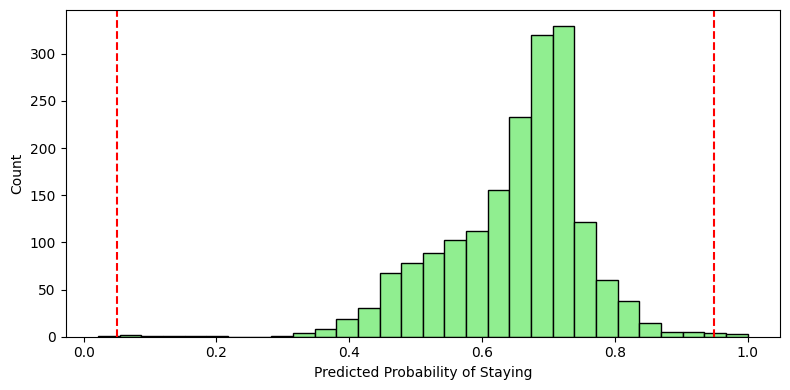

In [180]:
# ---------------------------
# Summary statistics (no log)
# ---------------------------
print("=== Non-Logged Model: p_stay_nolog ===")
print(df_model_nolog['p_stay_nolog'].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

# ---------------------------
# Plot distribution and save
# ---------------------------
plt.figure(figsize=(8, 4))
plt.hist(df_model_nolog['p_stay_nolog'], bins=30, color='lightgreen', edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--')
plt.axvline(0.95, color='red', linestyle='--')
plt.title("")
plt.xlabel("Predicted Probability of Staying")
plt.ylabel("Count")
plt.tight_layout()

# Save as PNG
plt.savefig("p_stay_nolog_distribution.png", dpi=300)
plt.show()

In [181]:
# Assuming your predicted probabilities are in df["p_stay_nolog"]
probs = df_model_nolog["p_stay_nolog"]

# Define thresholds
lower, upper = 0.05, 0.95

# Count proportions
below = (probs < lower).mean()
above = (probs > upper).mean()
inside = ((probs >= lower) & (probs <= upper)).mean()

print(f"Proportion below {lower}: {below:.3f}")
print(f"Proportion above {upper}: {above:.3f}")
print(f"Proportion inside [{lower}, {upper}]: {inside:.3f}")


Proportion below 0.05: 0.001
Proportion above 0.95: 0.003
Proportion inside [0.05, 0.95]: 0.996


In [182]:
# ---------------------------------------
# 1) Extract Coefficients & SEs
# ---------------------------------------

params = logit_res_nolog.params
bse = logit_res_nolog.bse

results_table = pd.DataFrame({
    "Variable": params.index,
    "Coefficient": params.values,
    "Std_Error": bse.values,
    "z_stat": params.values / bse.values,
    "p_value": logit_res_nolog.pvalues.values
})

# ---------------------------------------
# 2) Model-Level Statistics
# ---------------------------------------

N = int(logit_res_nolog.nobs)

# Pseudo R-squared (McFadden)
if hasattr(logit_res_nolog, "prsquared"):
    pseudo_r2 = logit_res_nolog.prsquared
else:
    pseudo_r2 = np.nan  # in case of regularized fallback

model_stats = pd.DataFrame({
    "Variable": ["N", "Pseudo_R2"],
    "Coefficient": [N, pseudo_r2],
    "Std_Error": ["", ""],
    "z_stat": ["", ""],
    "p_value": ["", ""]
})

# ---------------------------------------
# 3) Combine & Export
# ---------------------------------------

final_output = pd.concat([results_table, model_stats], ignore_index=True)
print(final_output)

                            Variable  Coefficient Std_Error    z_stat  \
0        Baseline_WeatherNormSiteEUI    -0.004236  0.004587 -0.923561   
1      Baseline_WeatherNormSourceEUI    -0.011988  0.005123 -2.339978   
2                Baseline_EnergyStar    -0.003354  0.002771 -1.210326   
3   Baseline_GHGEmissions_MetricTons    -0.000441   0.00022 -2.007643   
4      Baseline_GHGIntensity_KgCO2Ft     0.438122  0.170862  2.564186   
5                  ReportedFloorArea     0.000002  0.000001  1.345784   
6                              HDD65    -0.001332  0.000505 -2.638559   
7                              CDD65     0.002251  0.001047  2.151076   
8                   Ownership_Public     0.861689  0.156862  5.493305   
9                                  N  1810.000000                       
10                         Pseudo_R2     0.044191                       

     p_value  
0   0.355715  
1   0.019285  
2   0.226154  
3   0.044681  
4   0.010342  
5   0.178372  
6   0.008326  
7  

In [247]:
final_output.to_excel("Attrition_Logit_Results.xlsx", index=False)

In [186]:
# Print column names separated by commas
print(", ".join(beps_f6.columns))

X, Y, PID, SSL, PMPROPERTYID, REPORTINGYEAR, REPORTSTATUS, ADDRESSOFRECORD, WARD, REPORTEDADDRESS, POSTALCODE, YEARBUILT, PropType_SelfSelect, PropType_EPACalc, TaxFloorArea, ReportedFloorArea, EnergyStar, SiteEUI, WeatherNormSiteEUI, SourceEUI, WeatherNormSourceEUI, GHGEmissions_MetricTons, GHGIntensity_KgCO2Ft, WATERSCORE_MFPROPERTIES, WaterUse_KGAL, METEREDAREAS_ENERGY, METEREDAREAS_WATER, NatGasUse_Therms, FuelOilDiesel_KBTU, LATITUDE, LONGITUDE, XCOORD, YCOORD, DistChilledWater_KBTU, DistHotWater_KBTU, DistSteam_KBTU, ElecRenewable_KWH, ElecGrid_KWH, Total_NaturalGas_KBTU, Average_NaturalGas_KBTU, Total_Electricity_KBTU, Average_Electricity_KBTU, log_WEATHERNORMALZEDSITEEUI_KBTUFT, DCZone, PropType_EPACalc_Collapsed, panel_id, HDD65, CDD65, SSL_norm, Ownership_Type, Missing_EnergyStar, Ownership_Public, Post, Fed, Local, Post2020, Post2019, FirstObsYear, Entrant, Incumbent, Baseline_WeatherNormSiteEUI, Baseline_WeatherNormSourceEUI, Baseline_EnergyStar, Baseline_GHGEmissions_Metri

# TWFE Regression

In [187]:
# === TWFE REGRESSIONS: Overall BEPS effect via Post × Exposure (A/B/C) ===
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

In [188]:
# TWFE First Base Model

In [189]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'        # entity / building ID

# Dependent variables to run use 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT' instead
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# Prepare a MultiIndex (entity, time) for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    cols_needed = [dv, inter_col]
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col]]  # NO other controls

    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 ---
    # y_tilde = y - entity_mean - time_mean + grand_mean
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    # Residuals from the fitted model aligned to dsub index
    resid = res.resids.reindex(dsub.index)

    # Compute within SST and SSR (guard against zero variance)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    # Counts
    n_obs = int(dsub.shape[0])
    n_entities = int(dsub.index.get_level_values(0).nunique())

    out = {
        'res': res,
        'n_obs': n_obs,
        'n_entities': n_entities,
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'r2_within': r2_within
    }
    return out

rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE': np.nan,
                'tstat': np.nan,
                'pval': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE': out['se'],
            'tstat': out['t'],
            'pval': out['p'],
            'R2_within': out['r2_within']
        })

twfe_results = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)
print(twfe_results)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A  10686        1810            0.410122   
1                EnergyStar      B  10686        1810            0.322060   
2                EnergyStar      C  10686        1810            0.379409   
3   GHGEmissions_MetricTons      A  11937        1997           -0.350993   
4   GHGEmissions_MetricTons      B  11937        1997           -0.285978   
5   GHGEmissions_MetricTons      C  11937        1997           -0.257169   
6      GHGIntensity_KgCO2Ft      A  11937        1997           -0.653393   
7      GHGIntensity_KgCO2Ft      B  11937        1997           -0.511081   
8      GHGIntensity_KgCO2Ft      C  11937        1997           -0.565472   
9        WeatherNormSiteEUI      A  11937        1997           -0.333739   
10       WeatherNormSiteEUI      B  11937        1997           -0.235398   
11       WeatherNormSiteEUI      C  11937        1997           -0.250065   

In [190]:
# C-DID Base Model + federal and local controls

In [191]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run use 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT' instead
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# Prepare a MultiIndex (entity, time) for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    controls = ['FedxPublic', 'LocalxPublic']
    cols_needed = [dv, inter_col] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)

    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE_PostXExposure': np.nan,
                'tstat_PostXExposure': np.nan,
                'pval_PostXExposure': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE_PostXExposure': out['se'],
            'tstat_PostXExposure': out['t'],
            'pval_PostXExposure': out['p'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# Save final results with a clear name
twfe_results_ctrls_ext = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)

print(twfe_results_ctrls_ext)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A  10686        1810            0.410418   
1                EnergyStar      B  10686        1810            0.322350   
2                EnergyStar      C  10686        1810            0.380780   
3   GHGEmissions_MetricTons      A  11937        1997           -0.349773   
4   GHGEmissions_MetricTons      B  11937        1997           -0.284557   
5   GHGEmissions_MetricTons      C  11937        1997           -0.255598   
6      GHGIntensity_KgCO2Ft      A  11937        1997           -0.654148   
7      GHGIntensity_KgCO2Ft      B  11937        1997           -0.511391   
8      GHGIntensity_KgCO2Ft      C  11937        1997           -0.565760   
9        WeatherNormSiteEUI      A  11937        1997           -0.333267   
10       WeatherNormSiteEUI      B  11937        1997           -0.235841   
11       WeatherNormSiteEUI      C  11937        1997           -0.248985   

In [192]:
# Weighted C-DID with controls

In [193]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT'
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# Prepare a MultiIndex (entity, time) for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    controls = ['FedxPublic', 'LocalxPublic']
    cols_needed = [dv, inter_col, 'ipw_nolog'] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Guard against non-positive or infinite weights
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 (unweighted) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)

    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE_PostXExposure': np.nan,
                'tstat_PostXExposure': np.nan,
                'pval_PostXExposure': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE_PostXExposure': out['se'],
            'tstat_PostXExposure': out['t'],
            'pval_PostXExposure': out['p'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# Final dataframe with IPW and added controls
twfe_results_ipw_ctrls_ext = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)

print(twfe_results_ipw_ctrls_ext)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A  10686        1810            0.423956   
1                EnergyStar      B  10686        1810            0.333886   
2                EnergyStar      C  10686        1810            0.390074   
3   GHGEmissions_MetricTons      A  11281        1810           -0.544825   
4   GHGEmissions_MetricTons      B  11281        1810           -0.431840   
5   GHGEmissions_MetricTons      C  11281        1810           -0.425082   
6      GHGIntensity_KgCO2Ft      A  11281        1810           -0.758909   
7      GHGIntensity_KgCO2Ft      B  11281        1810           -0.663010   
8      GHGIntensity_KgCO2Ft      C  11281        1810           -0.687936   
9        WeatherNormSiteEUI      A  11281        1810           -0.316655   
10       WeatherNormSiteEUI      B  11281        1810           -0.230498   
11       WeatherNormSiteEUI      C  11281        1810           -0.244932   

In [218]:
# Save all results into one Excel file with different sheets
with pd.ExcelWriter("TWFE Main Result.xlsx", engine="openpyxl") as writer:
    twfe_results.to_excel(writer, sheet_name="TWFE_Results", index=False)
    twfe_results_ctrls_ext.to_excel(writer, sheet_name="TWFE_OverPolicy", index=False)
    twfe_results_ipw_ctrls_ext.to_excel(writer, sheet_name="TWFE_OverPolicy_IPW", index=False)


# Event study overall for main

In [220]:
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

In [222]:
# -----------------------------
# Inputs you gave
# -----------------------------
YEAR_COL = 'REPORTINGYEAR'   # time variable
ID_COL   = 'PMPROPERTYID'    # entity / building ID
REF_YEAR = 2018              # reference pre-policy year (normalize to 0)

# Outcomes & matching exposures for Method A # 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT'
pairs = [
    ('WeatherNormSiteEUI',        'ExposureA_WeatherNormSiteEUI'),
    ('WeatherNormSourceEUI',      'ExposureA_WeatherNormSourceEUI'), 
    ('EnergyStar',                      'ExposureA_EnergyStar'),
    ('GHGEmissions_MetricTons',             'ExposureA_GHGEmissions_MetricTons'),
    ('GHGIntensity_KgCO2Ft',            'ExposureA_GHGIntensity_KgCO2Ft')
]

def run_event_study_once(df, y_col, exposure_col, id_col, year_col, ref_year=2018):
    """Build Exposure×Year interactions (year FE ref = ref_year),
       run TWFE (entity & time FE), and return (result, plot_df)."""
    # Keep minimal columns and drop rows with missing values in these
    df_work = df[[id_col, year_col, y_col, exposure_col]].dropna().copy()
    df_work[year_col] = df_work[year_col].astype(int)

    # --- Year dummies, drop ref year
    year_dummies = pd.get_dummies(df_work[year_col], prefix='yr', drop_first=False)
    if f'yr_{ref_year}' not in year_dummies.columns:
        raise ValueError(f"REF_YEAR {ref_year} not present in the data.")
    year_dummies = year_dummies.drop(columns=[f'yr_{ref_year}'])

    # --- Exposure × Year(s)
    X_interactions = year_dummies.multiply(df_work[exposure_col], axis=0)
    X_interactions.columns = [c.replace('yr_', 'exp_') for c in X_interactions.columns]

    # --- Assemble model frame
    X = X_interactions.copy()
    df_model = pd.concat([df_work[[id_col, year_col, y_col]], X], axis=1).dropna()
    df_model = df_model.set_index([id_col, year_col]).sort_index()

    # --- TWFE: entity & time effects
    mod = PanelOLS(
        dependent=df_model[y_col],
        exog=df_model[X.columns],
        entity_effects=True,   # building FE
        time_effects=True      # year FE
    )
    res = mod.fit(cov_type='clustered', cluster_entity=True)

    # --- Extract coeffs & CIs for the exp_* terms only
    coefs = res.params.copy()
    conf  = res.conf_int()

    # Normalize CI column names
    if isinstance(conf, pd.DataFrame):
        if conf.shape[1] != 2:
            raise ValueError("Unexpected shape of conf_int(); expected 2 columns.")
        # Try to infer names; otherwise force
        rename_map = {}
        for col in conf.columns:
            lc = str(col).lower()
            if 'low' in lc or 'lower' in lc:
                rename_map[col] = 'ci_low'
            elif 'up' in lc or 'upper' in lc or 'hi' in lc:
                rename_map[col] = 'ci_high'
        if len(rename_map) < 2:
            conf.columns = ['ci_low', 'ci_high']
        else:
            conf = conf.rename(columns=rename_map)
        conf = conf.reindex(coefs.index)
    else:
        conf = pd.DataFrame(conf, index=coefs.index, columns=['ci_low', 'ci_high'])

    # Keep only the interaction terms
    keep_idx = [name for name in coefs.index if isinstance(name, str) and name.startswith('exp_')]
    coefs = coefs.loc[keep_idx]
    conf  = conf.loc[keep_idx]

    # Build plot df
    def year_from_col(col):
        try:
            return int(str(col).split('_')[-1])
        except Exception:
            return np.nan

    plot_df = pd.DataFrame({
        'year':   [year_from_col(c) for c in coefs.index],
        'beta':   coefs.values,
        'ci_low': conf['ci_low'].values,
        'ci_high':conf['ci_high'].values
    }).dropna(subset=['year']).sort_values('year')

    # Add the reference year at zero for continuity
    ref_row = pd.DataFrame({'year':[ref_year], 'beta':[0.0], 'ci_low':[0.0], 'ci_high':[0.0]})
    plot_df = pd.concat([plot_df, ref_row], ignore_index=True).sort_values('year')
    plot_df['outcome'] = y_col

    return res, plot_df


# -----------------------------
# Run for all 5 outcomes
# -----------------------------
results = {}          # regression objects by outcome
plot_dfs = {}         # plot-ready data by outcome
all_plot_values = []  # combined long dataframe

for y_col, exp_col in pairs:
    res, pdf = run_event_study_once(
        df=beps_f6,
        y_col=y_col,
        exposure_col=exp_col,
        id_col=ID_COL,
        year_col=YEAR_COL,
        ref_year=REF_YEAR
    )
    print(f"\n=== Event study (TWFE) for {y_col} using {exp_col} ===")
    print(res.summary)          # <-- print each regression result

    results[y_col]  = res
    plot_dfs[y_col] = pdf
    all_plot_values.append(pdf)

# One long DF with values for all outcomes (handy to save or facet-plot later)
event_study_plot_values = pd.concat(all_plot_values, ignore_index=True)
print(event_study_plot_values)


=== Event study (TWFE) for WeatherNormSiteEUI using ExposureA_WeatherNormSiteEUI ===
                          PanelOLS Estimation Summary                           
Dep. Variable:     WeatherNormSiteEUI   R-squared:                        0.0799
Estimator:                   PanelOLS   R-squared (Between):             -0.0341
No. Observations:               11937   R-squared (Within):               0.1615
Date:                Mon, Mar 30 2026   R-squared (Overall):             -0.0418
Time:                        22:56:03   Log-likelihood                -4.374e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      86.097
Entities:                        1997   P-value                           0.0000
Avg Obs:                       5.9775   Distribution:                 F(10,9920)
Min Obs:                       1.0000                                           
Max Obs:               

# with fed and local control

In [226]:
# -----------------------------
# Inputs you gave (updated version)
# -----------------------------
YEAR_COL = 'REPORTINGYEAR'   # time variable
ID_COL   = 'PMPROPERTYID'    # entity / building ID
REF_YEAR = 2018              # reference pre-policy year (normalize to 0)

# Outcomes & matching exposures for Method A
pairs = [
    ('WeatherNormSiteEUI',        'ExposureA_WeatherNormSiteEUI'),
    ('WeatherNormSourceEUI',      'ExposureA_WeatherNormSourceEUI'),
    ('EnergyStar',                'ExposureA_EnergyStar'),
    ('GHGEmissions_MetricTons',   'ExposureA_GHGEmissions_MetricTons'),
    ('GHGIntensity_KgCO2Ft',      'ExposureA_GHGIntensity_KgCO2Ft')
]


def run_event_study_once(df, y_col, exposure_col, id_col, year_col, ref_year=2018):
    """Build Exposure×Year interactions (year FE ref = ref_year),
       run TWFE (entity & time FE) with FedxPublic and LocalxPublic as controls,
       and return (result, plot_df)."""

    # Keep minimal columns and drop rows with missing values in these
    needed_cols = [id_col, year_col, y_col, exposure_col, 'FedxPublic', 'LocalxPublic']
    df_work = df[needed_cols].dropna().copy()
    df_work[year_col] = df_work[year_col].astype(int)

    # --- Year dummies, drop ref year
    year_dummies = pd.get_dummies(df_work[year_col], prefix='yr', drop_first=False)
    if f'yr_{ref_year}' not in year_dummies.columns:
        raise ValueError(f"REF_YEAR {ref_year} not present in the data.")
    year_dummies = year_dummies.drop(columns=[f'yr_{ref_year}'])

    # --- Exposure × Year(s)
    X_interactions = year_dummies.multiply(df_work[exposure_col], axis=0)
    X_interactions.columns = [c.replace('yr_', 'exp_') for c in X_interactions.columns]

    # --- Assemble model frame (include controls)
    X = pd.concat([X_interactions, df_work[['FedxPublic', 'LocalxPublic']]], axis=1)
    df_model = pd.concat([df_work[[id_col, year_col, y_col]], X], axis=1).dropna()
    df_model = df_model.set_index([id_col, year_col]).sort_index()

    # --- TWFE with controls
    mod = PanelOLS(
        dependent=df_model[y_col],
        exog=df_model[X.columns],
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(cov_type='clustered', cluster_entity=True)

    # --- Extract coeffs & CIs for the exp_* terms only
    coefs = res.params.copy()
    conf = res.conf_int()

    # Normalize CI column names
    if isinstance(conf, pd.DataFrame):
        if conf.shape[1] != 2:
            raise ValueError("Unexpected shape of conf_int(); expected 2 columns.")
        rename_map = {}
        for col in conf.columns:
            lc = str(col).lower()
            if 'low' in lc or 'lower' in lc:
                rename_map[col] = 'ci_low'
            elif 'up' in lc or 'upper' in lc or 'hi' in lc:
                rename_map[col] = 'ci_high'
        if len(rename_map) < 2:
            conf.columns = ['ci_low', 'ci_high']
        else:
            conf = conf.rename(columns=rename_map)
        conf = conf.reindex(coefs.index)
    else:
        conf = pd.DataFrame(conf, index=coefs.index, columns=['ci_low', 'ci_high'])

    # Keep only interaction terms
    keep_idx = [name for name in coefs.index if isinstance(name, str) and name.startswith('exp_')]
    coefs = coefs.loc[keep_idx]
    conf = conf.loc[keep_idx]

    # Build plot df
    def year_from_col(col):
        try:
            return int(str(col).split('_')[-1])
        except Exception:
            return np.nan

    plot_df = pd.DataFrame({
        'year': [year_from_col(c) for c in coefs.index],
        'beta': coefs.values,
        'ci_low': conf['ci_low'].values,
        'ci_high': conf['ci_high'].values
    }).dropna(subset=['year']).sort_values('year')

    # Add reference year (β=0) for continuity
    ref_row = pd.DataFrame({'year': [ref_year], 'beta': [0.0], 'ci_low': [0.0], 'ci_high': [0.0]})
    plot_df = pd.concat([plot_df, ref_row], ignore_index=True).sort_values('year')
    plot_df['outcome'] = y_col

    return res, plot_df


# -----------------------------
# Run for all 5 outcomes
# -----------------------------
results = {}
plot_dfs = {}
all_plot_values = []

for y_col, exp_col in pairs:
    res, pdf = run_event_study_once(
        df=beps_f6,
        y_col=y_col,
        exposure_col=exp_col,
        id_col=ID_COL,
        year_col=YEAR_COL,
        ref_year=REF_YEAR
    )

    print(f"\n=== Event study (TWFE) for {y_col} using {exp_col} ===")
    print(res.summary)

    results[y_col] = res
    plot_dfs[y_col] = pdf
    all_plot_values.append(pdf)

# Combine for plotting or saving
event_study_plot_values_ctrls = pd.concat(all_plot_values, ignore_index=True)
print(event_study_plot_values_ctrls)


=== Event study (TWFE) for WeatherNormSiteEUI using ExposureA_WeatherNormSiteEUI ===
                          PanelOLS Estimation Summary                           
Dep. Variable:     WeatherNormSiteEUI   R-squared:                        0.0817
Estimator:                   PanelOLS   R-squared (Between):             -0.0356
No. Observations:               11937   R-squared (Within):               0.1672
Date:                Mon, Mar 30 2026   R-squared (Overall):             -0.0433
Time:                        22:56:07   Log-likelihood                -4.372e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      73.523
Entities:                        1997   P-value                           0.0000
Avg Obs:                       5.9775   Distribution:                 F(12,9918)
Min Obs:                       1.0000                                           
Max Obs:               

# Event Study Plot

In [230]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter

/var/folders/wz/j37lcf513952clhw4f5gg7v40000gn/T/ipykernel_9052/835089287.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


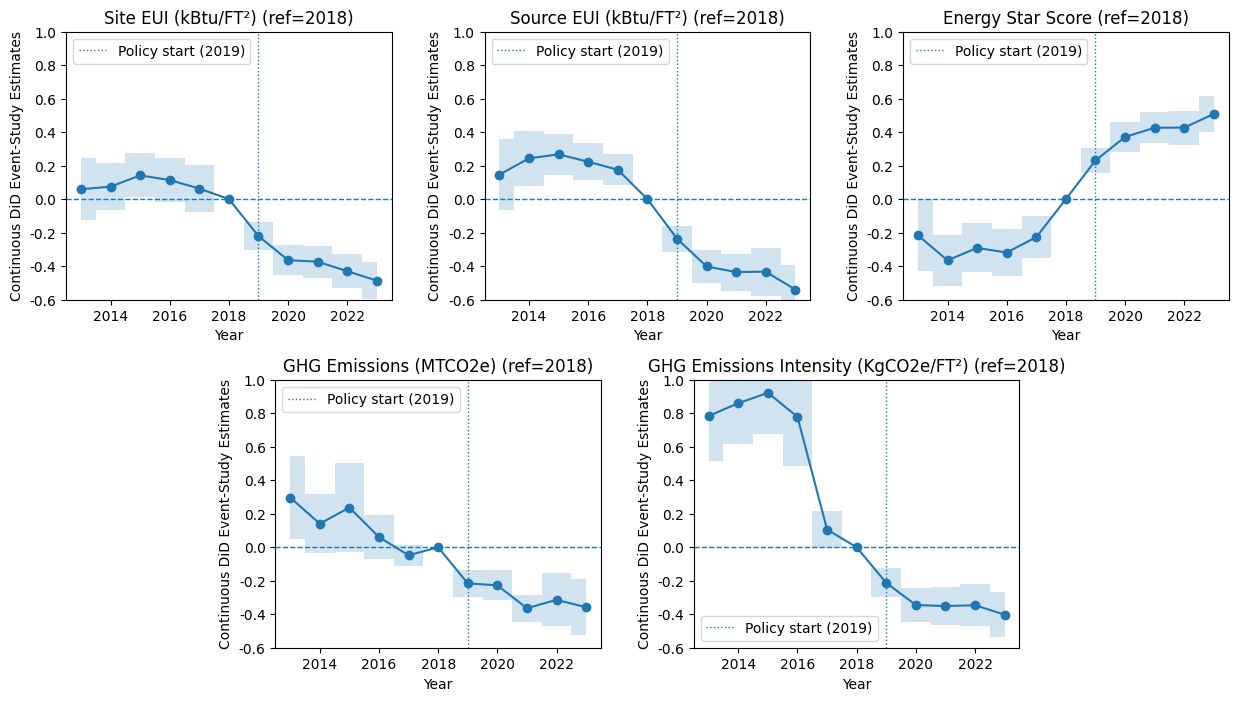

In [232]:
# -----------------------------
# Editable name map for clean titles
# -----------------------------
dv_name_map = {
    "WeatherNormSiteEUI": "Site EUI (kBtu/FT²)",
    "WeatherNormSourceEUI": "Source EUI (kBtu/FT²)",
    "EnergyStar": "Energy Star Score",
    "GHGEmissions_MetricTons": "GHG Emissions (MTCO2e)",
    "GHGIntensity_KgCO2Ft": "GHG Emissions Intensity (KgCO2e/FT²)"
}

# -----------------------------
# Plot up to 5 datasets and save as PNG
# -----------------------------
if not isinstance(plot_dfs, dict) or len(plot_dfs) == 0:
    raise ValueError("plot_dfs is empty or not defined. Build event-study results first.")

fig = plt.figure(figsize=(15, 8))

gs = GridSpec(
    nrows=2, ncols=6, figure=fig,
    hspace=0.3,
    wspace=0.8
)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5])
]

items_to_plot = list(plot_dfs.items())[:5]
for ax, (y_col, pdf) in zip(axes, items_to_plot):
    pdf = pdf.sort_values('year')

    ax.axhline(0, linewidth=1, linestyle='--')
    ax.axvline(2019, linewidth=1, linestyle=':', label='Policy start (2019)')

    ax.fill_between(
        pdf['year'], pdf['ci_low'], pdf['ci_high'],
        alpha=0.2, step='mid'
    )
    ax.plot(pdf['year'], pdf['beta'], marker='o')

    clean_name = dv_name_map.get(y_col, y_col)
    ax.set_title(f"{clean_name} (ref={REF_YEAR})")

    ax.set_xlabel("Year")
    ax.set_ylabel("Continuous DiD Event-Study Estimates")

    # ---- Enforce common y-axis limits and formatting ----
    ax.set_ylim(-0.6, 1.0)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    ax.legend(loc='best')

for ax in axes[len(items_to_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("event_study_overall.png", dpi=300, bbox_inches='tight')
plt.show()

# Robustness

# Analysis using 2019 post

In [295]:
# Unweighted

In [297]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide)
methods = ['A', 'B', 'C']

# Prepare a MultiIndex (entity, time) for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col = f'Post2019XExposure{method}_{dv}'  # use Post2019 version
    controls = ['FedxPublic', 'LocalxPublic']
    cols_needed = [dv, inter_col] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True
    )

    # --- Manual TWFE within R² ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_Post2019XExposure': np.nan,
                'SE_Post2019XExposure': np.nan,
                'tstat_Post2019XExposure': np.nan,
                'pval_Post2019XExposure': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_Post2019XExposure': out['coef'],
            'SE_Post2019XExposure': out['se'],
            'tstat_Post2019XExposure': out['t'],
            'pval_Post2019XExposure': out['p'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# --- Save final results with a descriptive name ---
twfe_results_ctrls_Post2019 = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ctrls_Post2019)

                         DV Method  N_obs  N_entities  Beta_Post2019XExposure  \
0                EnergyStar      A  10686        1810                0.545087   
1                EnergyStar      B  10686        1810                0.416824   
2                EnergyStar      C  10686        1810                0.534532   
3   GHGEmissions_MetricTons      A  11937        1997               -0.323828   
4   GHGEmissions_MetricTons      B  11937        1997               -0.296566   
5   GHGEmissions_MetricTons      C  11937        1997               -0.290555   
6      GHGIntensity_KgCO2Ft      A  11937        1997               -0.856911   
7      GHGIntensity_KgCO2Ft      B  11937        1997               -0.675348   
8      GHGIntensity_KgCO2Ft      C  11937        1997               -0.745243   
9        WeatherNormSiteEUI      A  11937        1997               -0.417588   
10       WeatherNormSiteEUI      B  11937        1997               -0.288947   
11       WeatherNormSiteEUI 

# Weighted

In [299]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# Prepare MultiIndex for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col = f'Post2019XExposure{method}_{dv}'  # use Post2019 version
    controls = ['FedxPublic', 'LocalxPublic']
    cols_needed = [dv, inter_col, 'ipw_nolog'] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Handle weights (guard against inf or 0)
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    # --- Manual TWFE within R² (unweighted) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_Post2019XExposure': np.nan,
                'SE_Post2019XExposure': np.nan,
                'tstat_Post2019XExposure': np.nan,
                'pval_Post2019XExposure': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_Post2019XExposure': out['coef'],
            'SE_Post2019XExposure': out['se'],
            'tstat_Post2019XExposure': out['t'],
            'pval_Post2019XExposure': out['p'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# --- Final dataframe ---
twfe_results_ipw_ctrls_Post2019 = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ipw_ctrls_Post2019)

                         DV Method  N_obs  N_entities  Beta_Post2019XExposure  \
0                EnergyStar      A  10686        1810                0.549857   
1                EnergyStar      B  10686        1810                0.423035   
2                EnergyStar      C  10686        1810                0.536282   
3   GHGEmissions_MetricTons      A  11281        1810               -0.705253   
4   GHGEmissions_MetricTons      B  11281        1810               -0.570991   
5   GHGEmissions_MetricTons      C  11281        1810               -0.598804   
6      GHGIntensity_KgCO2Ft      A  11281        1810               -1.021778   
7      GHGIntensity_KgCO2Ft      B  11281        1810               -0.901553   
8      GHGIntensity_KgCO2Ft      C  11281        1810               -0.929780   
9        WeatherNormSiteEUI      A  11281        1810               -0.398511   
10       WeatherNormSiteEUI      B  11281        1810               -0.284281   
11       WeatherNormSiteEUI 

# Analysis using 2020 post

# unweighted

In [305]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide)
methods = ['A', 'B', 'C']

# Prepare a MultiIndex (entity, time) for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col = f'Post2020XExposure{method}_{dv}'  # use Post2020 version
    controls = ['FedxPublic', 'LocalxPublic']
    cols_needed = [dv, inter_col] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True
    )

    # --- Manual TWFE within R² ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_Post2020XExposure': np.nan,
                'SE_Post2020XExposure': np.nan,
                'tstat_Post2020XExposure': np.nan,
                'pval_Post2020XExposure': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_Post2020XExposure': out['coef'],
            'SE_Post2020XExposure': out['se'],
            'tstat_Post2020XExposure': out['t'],
            'pval_Post2020XExposure': out['p'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# --- Save final results with a descriptive name ---
twfe_results_ctrls_Post2020 = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ctrls_Post2020)

                         DV Method  N_obs  N_entities  Beta_Post2020XExposure  \
0                EnergyStar      A  10686        1810                0.476236   
1                EnergyStar      B  10686        1810                0.360552   
2                EnergyStar      C  10686        1810                0.464457   
3   GHGEmissions_MetricTons      A  11937        1997               -0.305287   
4   GHGEmissions_MetricTons      B  11937        1997               -0.279752   
5   GHGEmissions_MetricTons      C  11937        1997               -0.268761   
6      GHGIntensity_KgCO2Ft      A  11937        1997               -0.754758   
7      GHGIntensity_KgCO2Ft      B  11937        1997               -0.597435   
8      GHGIntensity_KgCO2Ft      C  11937        1997               -0.674451   
9        WeatherNormSiteEUI      A  11937        1997               -0.385284   
10       WeatherNormSiteEUI      B  11937        1997               -0.270360   
11       WeatherNormSiteEUI 

# Weighted

In [307]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# Prepare MultiIndex for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col = f'Post2020XExposure{method}_{dv}'  # use Post2020 version
    controls = ['FedxPublic', 'LocalxPublic']
    cols_needed = [dv, inter_col, 'ipw_nolog'] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Handle weights (guard against inf or 0)
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    # --- Manual TWFE within R² (unweighted) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_Post2020XExposure': np.nan,
                'SE_Post2020XExposure': np.nan,
                'tstat_Post2020XExposure': np.nan,
                'pval_Post2020XExposure': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_Post2020XExposure': out['coef'],
            'SE_Post2020XExposure': out['se'],
            'tstat_Post2020XExposure': out['t'],
            'pval_Post2020XExposure': out['p'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# --- Final dataframe ---
twfe_results_ipw_ctrls_Post2020 = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ipw_ctrls_Post2020)

                         DV Method  N_obs  N_entities  Beta_Post2020XExposure  \
0                EnergyStar      A  10686        1810                0.483079   
1                EnergyStar      B  10686        1810                0.368145   
2                EnergyStar      C  10686        1810                0.465633   
3   GHGEmissions_MetricTons      A  11281        1810               -0.634737   
4   GHGEmissions_MetricTons      B  11281        1810               -0.511547   
5   GHGEmissions_MetricTons      C  11281        1810               -0.513959   
6      GHGIntensity_KgCO2Ft      A  11281        1810               -0.881780   
7      GHGIntensity_KgCO2Ft      B  11281        1810               -0.775384   
8      GHGIntensity_KgCO2Ft      C  11281        1810               -0.805665   
9        WeatherNormSiteEUI      A  11281        1810               -0.365153   
10       WeatherNormSiteEUI      B  11281        1810               -0.264252   
11       WeatherNormSiteEUI 

# Donut-year robustness (dropping 2020 Obs) - main model

# Unweighted

In [313]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# Prepare MultiIndex for PanelOLS and drop 2020 data
df = beps_f6.copy()
df = df[df[YEAR_COL] != 2020]       # <-- Exclude 2020 observations
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction term
    controls = ['FedxPublic', 'LocalxPublic']
    cols_needed = [dv, inter_col] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    # --- Manual within R² computation ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE_PostXExposure': np.nan,
                'tstat_PostXExposure': np.nan,
                'pval_PostXExposure': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE_PostXExposure': out['se'],
            'tstat_PostXExposure': out['t'],
            'pval_PostXExposure': out['p'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# --- Final dataframe ---
twfe_results_ctrls_ext_no2020 = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ctrls_ext_no2020)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A   9573        1810            0.501584   
1                EnergyStar      B   9573        1810            0.385863   
2                EnergyStar      C   9573        1810            0.475368   
3   GHGEmissions_MetricTons      A  10736        1997           -0.409298   
4   GHGEmissions_MetricTons      B  10736        1997           -0.336585   
5   GHGEmissions_MetricTons      C  10736        1997           -0.312074   
6      GHGIntensity_KgCO2Ft      A  10736        1997           -0.765355   
7      GHGIntensity_KgCO2Ft      B  10736        1997           -0.605084   
8      GHGIntensity_KgCO2Ft      C  10736        1997           -0.670924   
9        WeatherNormSiteEUI      A  10736        1997           -0.408806   
10       WeatherNormSiteEUI      B  10736        1997           -0.286317   
11       WeatherNormSiteEUI      C  10736        1997           -0.327062   

# Weighted

In [315]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# Prepare MultiIndex for PanelOLS and exclude 2020 data
df = beps_f6.copy()
df = df[df[YEAR_COL] != 2020]     # <-- Drop 2020 observations
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # main interaction
    controls = ['FedxPublic', 'LocalxPublic']
    cols_needed = [dv, inter_col, 'ipw_nolog'] + controls

    # Ensure all required columns exist
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Guard against invalid weights
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    # Weighted TWFE model
    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    # --- Manual within R² (unweighted version) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE_PostXExposure': np.nan,
                'tstat_PostXExposure': np.nan,
                'pval_PostXExposure': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE_PostXExposure': out['se'],
            'tstat_PostXExposure': out['t'],
            'pval_PostXExposure': out['p'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# --- Final dataframe ---
twfe_results_ipw_ctrls_ext_no2020 = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ipw_ctrls_ext_no2020)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A   9573        1810            0.515629   
1                EnergyStar      B   9573        1810            0.398270   
2                EnergyStar      C   9573        1810            0.484597   
3   GHGEmissions_MetricTons      A  10138        1810           -0.636452   
4   GHGEmissions_MetricTons      B  10138        1810           -0.509203   
5   GHGEmissions_MetricTons      C  10138        1810           -0.508123   
6      GHGIntensity_KgCO2Ft      A  10138        1810           -0.879157   
7      GHGIntensity_KgCO2Ft      B  10138        1810           -0.772895   
8      GHGIntensity_KgCO2Ft      C  10138        1810           -0.801010   
9        WeatherNormSiteEUI      A  10138        1810           -0.387569   
10       WeatherNormSiteEUI      B  10138        1810           -0.279458   
11       WeatherNormSiteEUI      C  10138        1810           -0.322688   

In [ ]:
# Save all results into one Excel file with different sheets
with pd.ExcelWriter("TWFE Robustness Result.xlsx", engine="openpyxl") as writer:
    twfe_results_ctrls_Post2019.to_excel(writer, sheet_name="TWFE_Post2019", index=False)
    twfe_results_ipw_ctrls_Post2019.to_excel(writer, sheet_name="TWFE_Post2019_IPW", index=False)
    twfe_results_ctrls_Post2020.to_excel(writer, sheet_name="TWFE_Post2020", index=False)
    twfe_results_ipw_ctrls_Post2020.to_excel(writer, sheet_name="TWFE_Post2020_IPW", index=False)
    twfe_results_ctrls_ext_no2020.to_excel(writer, sheet_name="TWFE_no2020", index=False)
    twfe_results_ipw_ctrls_ext_no2020.to_excel(writer, sheet_name="TWFE_IPW_no2020", index=False)

# AR(1) Specification

In [318]:
# unweighted with overlapping controls

In [323]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'
ID_COL   = 'PMPROPERTYID'

dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

methods = ['A', 'B', 'C']

# Prepare panel structure
df = beps_f6.copy()
df = df.sort_values([ID_COL, YEAR_COL])
df = df.set_index([ID_COL, YEAR_COL])

def fit_twfe_ar(dv, method):

    inter_col = f'PostXExposure{method}_{dv}'
    controls = ['FedxPublic', 'LocalxPublic']

    # Create AR(1) lagged DV
    df[f'{dv}_lag'] = df.groupby(level=0)[dv].shift(1)

    cols_needed = [dv, f'{dv}_lag', inter_col] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[f'{dv}_lag', inter_col] + controls]

    mod = PanelOLS(
        y,
        X,
        entity_effects=True,
        time_effects=True
    )

    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    # --- Manual TWFE within R^2 ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)

    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef_ar': res.params.get(inter_col, np.nan),
        'se_ar': res.std_errors.get(inter_col, np.nan),
        't_ar': res.tstats.get(inter_col, np.nan),
        'p_ar': res.pvalues.get(inter_col, np.nan),
        'coef_FedxPublic_ar': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic_ar': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic_ar': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic_ar': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic_ar': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic_ar': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic_ar': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic_ar': res.pvalues.get('LocalxPublic', np.nan),
        'coef_lag_ar': res.params.get(f'{dv}_lag', np.nan),
        'se_lag_ar': res.std_errors.get(f'{dv}_lag', np.nan),
        'r2_within_ar': r2_within
    }

    return out


rows = []

for dv in dv_list:
    for m in methods:

        out = fit_twfe_ar(dv, m)

        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs_ar': 0,
                'N_entities_ar': 0,
                'Beta_PostXExposure_ar': np.nan,
                'SE_PostXExposure_ar': np.nan,
                'tstat_PostXExposure_ar': np.nan,
                'pval_PostXExposure_ar': np.nan,
                'Beta_FedxPublic_ar': np.nan,
                'SE_FedxPublic_ar': np.nan,
                'tstat_FedxPublic_ar': np.nan,
                'pval_FedxPublic_ar': np.nan,
                'Beta_LocalxPublic_ar': np.nan,
                'SE_LocalxPublic_ar': np.nan,
                'tstat_LocalxPublic_ar': np.nan,
                'pval_LocalxPublic_ar': np.nan,
                'Beta_Lag_ar': np.nan,
                'SE_Lag_ar': np.nan,
                'R2_within_ar': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs_ar': out['n_obs'],
            'N_entities_ar': out['n_entities'],
            'Beta_PostXExposure_ar': out['coef_ar'],
            'SE_PostXExposure_ar': out['se_ar'],
            'tstat_PostXExposure_ar': out['t_ar'],
            'pval_PostXExposure_ar': out['p_ar'],
            'Beta_FedxPublic_ar': out['coef_FedxPublic_ar'],
            'SE_FedxPublic_ar': out['se_FedxPublic_ar'],
            'tstat_FedxPublic_ar': out['t_FedxPublic_ar'],
            'pval_FedxPublic_ar': out['p_FedxPublic_ar'],
            'Beta_LocalxPublic_ar': out['coef_LocalxPublic_ar'],
            'SE_LocalxPublic_ar': out['se_LocalxPublic_ar'],
            'tstat_LocalxPublic_ar': out['t_LocalxPublic_ar'],
            'pval_LocalxPublic_ar': out['p_LocalxPublic_ar'],
            'Beta_Lag_ar': out['coef_lag_ar'],
            'SE_Lag_ar': out['se_lag_ar'],
            'R2_within_ar': out['r2_within_ar']
        })

# Save final AR(1) results
twfe_results_ctrls_ext_ar = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ctrls_ext_ar)

                         DV Method  N_obs_ar  N_entities_ar  \
0                EnergyStar      A      8834           1558   
1                EnergyStar      B      8834           1558   
2                EnergyStar      C      8834           1558   
3   GHGEmissions_MetricTons      A      9940           1693   
4   GHGEmissions_MetricTons      B      9940           1693   
5   GHGEmissions_MetricTons      C      9940           1693   
6      GHGIntensity_KgCO2Ft      A      9940           1693   
7      GHGIntensity_KgCO2Ft      B      9940           1693   
8      GHGIntensity_KgCO2Ft      C      9940           1693   
9        WeatherNormSiteEUI      A      9940           1693   
10       WeatherNormSiteEUI      B      9940           1693   
11       WeatherNormSiteEUI      C      9940           1693   
12     WeatherNormSourceEUI      A      9940           1693   
13     WeatherNormSourceEUI      B      9940           1693   
14     WeatherNormSourceEUI      C      9940           

# weighted with overlapping controls

In [329]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'
ID_COL   = 'PMPROPERTYID'

dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

methods = ['A', 'B', 'C']

# Prepare MultiIndex
df = beps_f6.copy()
df = df.sort_values([ID_COL, YEAR_COL])
df = df.set_index([ID_COL, YEAR_COL])


def fit_twfe_ipw_ar(dv, method):

    inter_col = f'PostXExposure{method}_{dv}'
    controls = ['FedxPublic', 'LocalxPublic']
    lag_col = f'L1_{dv}'

    # -------- Create AR(1) Lag --------
    df[lag_col] = df.groupby(level=0)[dv].shift(1)

    cols_needed = [dv, lag_col, inter_col, 'ipw_nolog'] + controls

    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # -------- Clean weights --------
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan)
    dsub = dsub.loc[w.notna()]
    w = w.loc[dsub.index].clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[lag_col, inter_col] + controls]

    mod = PanelOLS(
        y,
        X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )

    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    # -------- Manual TWFE Within R² (Unweighted) --------
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)

    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res_ar': res,
        'n_obs_ar': int(dsub.shape[0]),
        'n_entities_ar': int(dsub.index.get_level_values(0).nunique()),

        # Main interaction
        'coef_ar': res.params.get(inter_col, np.nan),
        'se_ar': res.std_errors.get(inter_col, np.nan),
        't_ar': res.tstats.get(inter_col, np.nan),
        'p_ar': res.pvalues.get(inter_col, np.nan),

        # Lag term
        'coef_lag_ar': res.params.get(lag_col, np.nan),
        'se_lag_ar': res.std_errors.get(lag_col, np.nan),
        't_lag_ar': res.tstats.get(lag_col, np.nan),
        'p_lag_ar': res.pvalues.get(lag_col, np.nan),

        # Controls
        'coef_FedxPublic_ar': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic_ar': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic_ar': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic_ar': res.pvalues.get('FedxPublic', np.nan),

        'coef_LocalxPublic_ar': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic_ar': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic_ar': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic_ar': res.pvalues.get('LocalxPublic', np.nan),

        'r2_within_ar': r2_within
    }

    return out


rows = []

for dv in dv_list:
    for m in methods:

        out = fit_twfe_ipw_ar(dv, m)

        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs_ar': 0,
                'N_entities_ar': 0,
                'Beta_PostXExposure_ar': np.nan,
                'SE_PostXExposure_ar': np.nan,
                't_PostXExposure_ar': np.nan,
                'p_PostXExposure_ar': np.nan,
                'Beta_Lag_ar': np.nan,
                'SE_Lag_ar': np.nan,
                't_Lag_ar': np.nan,
                'p_Lag_ar': np.nan,
                'Beta_FedxPublic_ar': np.nan,
                'SE_FedxPublic_ar': np.nan,
                't_FedxPublic_ar': np.nan,
                'p_FedxPublic_ar': np.nan,
                'Beta_LocalxPublic_ar': np.nan,
                'SE_LocalxPublic_ar': np.nan,
                't_LocalxPublic_ar': np.nan,
                'p_LocalxPublic_ar': np.nan,
                'R2_within_ar': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs_ar': out['n_obs_ar'],
            'N_entities_ar': out['n_entities_ar'],
            'Beta_PostXExposure_ar': out['coef_ar'],
            'SE_PostXExposure_ar': out['se_ar'],
            't_PostXExposure_ar': out['t_ar'],
            'p_PostXExposure_ar': out['p_ar'],
            'Beta_Lag_ar': out['coef_lag_ar'],
            'SE_Lag_ar': out['se_lag_ar'],
            't_Lag_ar': out['t_lag_ar'],
            'p_Lag_ar': out['p_lag_ar'],
            'Beta_FedxPublic_ar': out['coef_FedxPublic_ar'],
            'SE_FedxPublic_ar': out['se_FedxPublic_ar'],
            't_FedxPublic_ar': out['t_FedxPublic_ar'],
            'p_FedxPublic_ar': out['p_FedxPublic_ar'],
            'Beta_LocalxPublic_ar': out['coef_LocalxPublic_ar'],
            'SE_LocalxPublic_ar': out['se_LocalxPublic_ar'],
            't_LocalxPublic_ar': out['t_LocalxPublic_ar'],
            'p_LocalxPublic_ar': out['p_LocalxPublic_ar'],
            'R2_within_ar': out['r2_within_ar']
        })


# Final AR(1) + IPW results table
twfe_results_ipw_ctrls_ext_ar = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ipw_ctrls_ext_ar)

                         DV Method  N_obs_ar  N_entities_ar  \
0                EnergyStar      A      8834           1558   
1                EnergyStar      B      8834           1558   
2                EnergyStar      C      8834           1558   
3   GHGEmissions_MetricTons      A      9471           1579   
4   GHGEmissions_MetricTons      B      9471           1579   
5   GHGEmissions_MetricTons      C      9471           1579   
6      GHGIntensity_KgCO2Ft      A      9471           1579   
7      GHGIntensity_KgCO2Ft      B      9471           1579   
8      GHGIntensity_KgCO2Ft      C      9471           1579   
9        WeatherNormSiteEUI      A      9471           1579   
10       WeatherNormSiteEUI      B      9471           1579   
11       WeatherNormSiteEUI      C      9471           1579   
12     WeatherNormSourceEUI      A      9471           1579   
13     WeatherNormSourceEUI      B      9471           1579   
14     WeatherNormSourceEUI      C      9471           

In [331]:
# Save all results into one Excel file with different sheets
with pd.ExcelWriter("TWFE Robustness Result2.xlsx", engine="openpyxl") as writer:
    twfe_results_ctrls_ext_ar.to_excel(writer, sheet_name="Unweighted AR", index=False)
    twfe_results_ipw_ctrls_ext_ar.to_excel(writer, sheet_name="Weighted AR", index=False)

# Another approach to public / private - this is where the interaction term is done

# unweighted, no overlapping controls

In [320]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide)
methods = ['A', 'B', 'C']

# Prepare a MultiIndex (entity, time) for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col  = f'PostXExposure{method}_{dv}'          # main interaction
    triple_col = f'PostXExposure{method}_{dv}_xPublic' # heterogeneous effect

    cols_needed = [dv, inter_col, triple_col]

    # Ensure all required columns exist
    if not all(c in df.columns for c in cols_needed):
        return None

    # Drop missing observations
    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col, triple_col]]

    # --- Run TWFE regression ---
    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True
    )

    # --- Compute manual within R² ---
    ent_mean   = y.groupby(level=0).transform('mean')
    time_mean  = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde    = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr        = float((resid ** 2).sum())
    r2_within  = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_triple': res.params.get(triple_col, np.nan),
        'se_triple': res.std_errors.get(triple_col, np.nan),
        't_triple': res.tstats.get(triple_col, np.nan),
        'p_triple': res.pvalues.get(triple_col, np.nan),
        'r2_within': r2_within
    }
    return out


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)

        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE_PostXExposure': np.nan,
                'tstat_PostXExposure': np.nan,
                'pval_PostXExposure': np.nan,
                'Beta_PostXExposure_xPublic': np.nan,
                'SE_PostXExposure_xPublic': np.nan,
                'tstat_PostXExposure_xPublic': np.nan,
                'pval_PostXExposure_xPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE_PostXExposure': out['se'],
            'tstat_PostXExposure': out['t'],
            'pval_PostXExposure': out['p'],
            'Beta_PostXExposure_xPublic': out['coef_triple'],
            'SE_PostXExposure_xPublic': out['se_triple'],
            'tstat_PostXExposure_xPublic': out['t_triple'],
            'pval_PostXExposure_xPublic': out['p_triple'],
            'R2_within': out['r2_within']
        })


# --- Final results dataframe ---
twfe_results_nopublic = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_nopublic)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A  10686        1810            0.414423   
1                EnergyStar      B  10686        1810            0.323861   
2                EnergyStar      C  10686        1810            0.391601   
3   GHGEmissions_MetricTons      A  11937        1997           -0.336817   
4   GHGEmissions_MetricTons      B  11937        1997           -0.277576   
5   GHGEmissions_MetricTons      C  11937        1997           -0.252818   
6      GHGIntensity_KgCO2Ft      A  11937        1997           -0.646658   
7      GHGIntensity_KgCO2Ft      B  11937        1997           -0.504601   
8      GHGIntensity_KgCO2Ft      C  11937        1997           -0.558313   
9        WeatherNormSiteEUI      A  11937        1997           -0.329113   
10       WeatherNormSiteEUI      B  11937        1997           -0.228149   
11       WeatherNormSiteEUI      C  11937        1997           -0.239869   

In [ ]:
# weighted, no overlapping controls

In [322]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods
methods = ['A', 'B', 'C']

# Prepare MultiIndex for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col  = f'PostXExposure{method}_{dv}'           # main effect
    triple_col = f'PostXExposure{method}_{dv}_xPublic'  # public heterogeneity

    cols_needed = [dv, inter_col, triple_col, 'ipw_nolog']

    # Ensure all columns exist
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # --- Handle IPW safely ---
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col, triple_col]]

    # --- Weighted TWFE regression ---
    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    # --- Manual within R² (unweighted, as standard) ---
    ent_mean   = y.groupby(level=0).transform('mean')
    time_mean  = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde    = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr        = float((resid ** 2).sum())
    r2_within  = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    return {
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),

        # Main effect
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),

        # Public heterogeneity
        'coef_triple': res.params.get(triple_col, np.nan),
        'se_triple': res.std_errors.get(triple_col, np.nan),
        't_triple': res.tstats.get(triple_col, np.nan),
        'p_triple': res.pvalues.get(triple_col, np.nan),

        # Fit
        'r2_within': r2_within
    }


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)

        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE_PostXExposure': np.nan,
                'tstat_PostXExposure': np.nan,
                'pval_PostXExposure': np.nan,
                'Beta_PostXExposure_xPublic': np.nan,
                'SE_PostXExposure_xPublic': np.nan,
                'tstat_PostXExposure_xPublic': np.nan,
                'pval_PostXExposure_xPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],

            # Main effect
            'Beta_PostXExposure': out['coef'],
            'SE_PostXExposure': out['se'],
            'tstat_PostXExposure': out['t'],
            'pval_PostXExposure': out['p'],

            # Public heterogeneity
            'Beta_PostXExposure_xPublic': out['coef_triple'],
            'SE_PostXExposure_xPublic': out['se_triple'],
            'tstat_PostXExposure_xPublic': out['t_triple'],
            'pval_PostXExposure_xPublic': out['p_triple'],

            # Fit
            'R2_within': out['r2_within']
        })


# --- Final dataframe ---
twfe_results_ipw_nopublic = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ipw_nopublic)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A  10686        1810            0.432212   
1                EnergyStar      B  10686        1810            0.337396   
2                EnergyStar      C  10686        1810            0.406684   
3   GHGEmissions_MetricTons      A  11281        1810           -0.541323   
4   GHGEmissions_MetricTons      B  11281        1810           -0.433040   
5   GHGEmissions_MetricTons      C  11281        1810           -0.424747   
6      GHGIntensity_KgCO2Ft      A  11281        1810           -0.754489   
7      GHGIntensity_KgCO2Ft      B  11281        1810           -0.659674   
8      GHGIntensity_KgCO2Ft      C  11281        1810           -0.684075   
9        WeatherNormSiteEUI      A  11281        1810           -0.322114   
10       WeatherNormSiteEUI      B  11281        1810           -0.226570   
11       WeatherNormSiteEUI      C  11281        1810           -0.241583   

In [ ]:
# unweighted but with overlapping controls

In [278]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide)
methods = ['A', 'B', 'C']

# Prepare a MultiIndex (entity, time) for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'                   # main interaction
    triple_col = f'PostXExposure{method}_{dv}_xPublic'          # triple interaction term
    controls = [triple_col, 'FedxPublic', 'LocalxPublic']       # controls with triple term first
    cols_needed = [dv, inter_col] + controls

    # Ensure all columns exist
    if not all(c in df.columns for c in cols_needed):
        return None

    # Drop missing observations
    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    # --- Run TWFE regression ---
    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True
    )

    # --- Compute manual within R² ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'coef_triple': res.params.get(triple_col, np.nan),
        'se_triple': res.std_errors.get(triple_col, np.nan),
        't_triple': res.tstats.get(triple_col, np.nan),
        'p_triple': res.pvalues.get(triple_col, np.nan),
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),
        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),
        'r2_within': r2_within
    }
    return out


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE_PostXExposure': np.nan,
                'tstat_PostXExposure': np.nan,
                'pval_PostXExposure': np.nan,
                'Beta_PostXExposure_xPublic': np.nan,
                'SE_PostXExposure_xPublic': np.nan,
                'tstat_PostXExposure_xPublic': np.nan,
                'pval_PostXExposure_xPublic': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE_PostXExposure': out['se'],
            'tstat_PostXExposure': out['t'],
            'pval_PostXExposure': out['p'],
            'Beta_PostXExposure_xPublic': out['coef_triple'],
            'SE_PostXExposure_xPublic': out['se_triple'],
            'tstat_PostXExposure_xPublic': out['t_triple'],
            'pval_PostXExposure_xPublic': out['p_triple'],
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],
            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],
            'R2_within': out['r2_within']
        })

# --- Save final results with descriptive name ---
twfe_results_ctrls_public = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ctrls_public)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A  10686        1810            0.414421   
1                EnergyStar      B  10686        1810            0.325641   
2                EnergyStar      C  10686        1810            0.392020   
3   GHGEmissions_MetricTons      A  11937        1997           -0.339109   
4   GHGEmissions_MetricTons      B  11937        1997           -0.278998   
5   GHGEmissions_MetricTons      C  11937        1997           -0.254462   
6      GHGIntensity_KgCO2Ft      A  11937        1997           -0.654676   
7      GHGIntensity_KgCO2Ft      B  11937        1997           -0.512994   
8      GHGIntensity_KgCO2Ft      C  11937        1997           -0.565394   
9        WeatherNormSiteEUI      A  11937        1997           -0.337173   
10       WeatherNormSiteEUI      B  11937        1997           -0.235915   
11       WeatherNormSiteEUI      C  11937        1997           -0.244648   

In [ ]:
# weighted but with overlapping controls

In [279]:
# Weighted for public & private

In [282]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: mean, B: percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# Prepare MultiIndex for PanelOLS
df = beps_f6.copy()
df = df.set_index([ID_COL, YEAR_COL]).sort_index()


def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'                   # main interaction
    triple_col = f'PostXExposure{method}_{dv}_xPublic'          # triple interaction
    controls = [triple_col, 'FedxPublic', 'LocalxPublic']       # include triple first
    cols_needed = [dv, inter_col, 'ipw_nolog'] + controls

    # Ensure all required columns exist
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Handle weights safely (avoid inf or zero)
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col] + controls]

    # Weighted TWFE regression
    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    # --- Manual within R² (unweighted version) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    out = {
        'res': res,
        'n_obs': int(dsub.shape[0]),
        'n_entities': int(dsub.index.get_level_values(0).nunique()),

        # Main treatment
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),

        # Triple interaction (Public × PostXExposure)
        'coef_triple': res.params.get(triple_col, np.nan),
        'se_triple': res.std_errors.get(triple_col, np.nan),
        't_triple': res.tstats.get(triple_col, np.nan),
        'p_triple': res.pvalues.get(triple_col, np.nan),

        # Controls
        'coef_FedxPublic': res.params.get('FedxPublic', np.nan),
        'se_FedxPublic': res.std_errors.get('FedxPublic', np.nan),
        't_FedxPublic': res.tstats.get('FedxPublic', np.nan),
        'p_FedxPublic': res.pvalues.get('FedxPublic', np.nan),

        'coef_LocalxPublic': res.params.get('LocalxPublic', np.nan),
        'se_LocalxPublic': res.std_errors.get('LocalxPublic', np.nan),
        't_LocalxPublic': res.tstats.get('LocalxPublic', np.nan),
        'p_LocalxPublic': res.pvalues.get('LocalxPublic', np.nan),

        # Model fit
        'r2_within': r2_within
    }
    return out


# ---------------- RUN TWFE ----------------
rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE_PostXExposure': np.nan,
                'tstat_PostXExposure': np.nan,
                'pval_PostXExposure': np.nan,
                'Beta_PostXExposure_xPublic': np.nan,
                'SE_PostXExposure_xPublic': np.nan,
                'tstat_PostXExposure_xPublic': np.nan,
                'pval_PostXExposure_xPublic': np.nan,
                'Beta_FedxPublic': np.nan,
                'SE_FedxPublic': np.nan,
                'tstat_FedxPublic': np.nan,
                'pval_FedxPublic': np.nan,
                'Beta_LocalxPublic': np.nan,
                'SE_LocalxPublic': np.nan,
                'tstat_LocalxPublic': np.nan,
                'pval_LocalxPublic': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],

            # Main effect
            'Beta_PostXExposure': out['coef'],
            'SE_PostXExposure': out['se'],
            'tstat_PostXExposure': out['t'],
            'pval_PostXExposure': out['p'],

            # Triple interaction
            'Beta_PostXExposure_xPublic': out['coef_triple'],
            'SE_PostXExposure_xPublic': out['se_triple'],
            'tstat_PostXExposure_xPublic': out['t_triple'],
            'pval_PostXExposure_xPublic': out['p_triple'],

            # Controls
            'Beta_FedxPublic': out['coef_FedxPublic'],
            'SE_FedxPublic': out['se_FedxPublic'],
            'tstat_FedxPublic': out['t_FedxPublic'],
            'pval_FedxPublic': out['p_FedxPublic'],

            'Beta_LocalxPublic': out['coef_LocalxPublic'],
            'SE_LocalxPublic': out['se_LocalxPublic'],
            'tstat_LocalxPublic': out['t_LocalxPublic'],
            'pval_LocalxPublic': out['p_LocalxPublic'],

            # Fit
            'R2_within': out['r2_within']
        })

# --- Final dataframe ---
twfe_results_ipw_ctrls_public = (
    pd.DataFrame(rows)
    .sort_values(['DV', 'Method'])
    .reset_index(drop=True)
)

print(twfe_results_ipw_ctrls_public)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A  10686        1810            0.433590   
1                EnergyStar      B  10686        1810            0.340767   
2                EnergyStar      C  10686        1810            0.408439   
3   GHGEmissions_MetricTons      A  11281        1810           -0.545489   
4   GHGEmissions_MetricTons      B  11281        1810           -0.436612   
5   GHGEmissions_MetricTons      C  11281        1810           -0.427084   
6      GHGIntensity_KgCO2Ft      A  11281        1810           -0.760434   
7      GHGIntensity_KgCO2Ft      B  11281        1810           -0.667153   
8      GHGIntensity_KgCO2Ft      C  11281        1810           -0.690783   
9        WeatherNormSiteEUI      A  11281        1810           -0.332036   
10       WeatherNormSiteEUI      B  11281        1810           -0.237315   
11       WeatherNormSiteEUI      C  11281        1810           -0.248057   

In [324]:
# Save all results into one Excel file with different sheets
with pd.ExcelWriter("TWFE Public Result.xlsx", engine="openpyxl") as writer:
    twfe_results_nopublic.to_excel(writer, sheet_name="TWFE_NoPublic", index=False)
    twfe_results_ipw_nopublic.to_excel(writer, sheet_name="TWFE_IPW_NoPublic", index=False)
    twfe_results_ctrls_public.to_excel(writer, sheet_name="TWFE_Public", index=False)
    twfe_results_ipw_ctrls_public.to_excel(writer, sheet_name="TWFE_IPW_Public", index=False)

# TWFE - Public Main

In [326]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT'
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# ---------------- PUBLIC-ONLY SUBSET ----------------
df_all = beps_f6.copy()

# robust 'Public' filter (handles case/whitespace)
public_mask = df_all['Ownership_Type'].astype(str).str.strip().str.lower().eq('public')
df_public = df_all.loc[public_mask].copy()

if df_public.empty:
    raise ValueError("No rows found for Ownership_Type == 'Public'. Check values/casing in Ownership_Type.")

# Prepare a MultiIndex (entity, time) for PanelOLS
df = df_public.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    cols_needed = [dv, inter_col]
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col]]  # NO other controls

    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    # Residuals from the fitted model aligned to dsub index
    resid = res.resids.reindex(dsub.index)

    # Compute within SST and SSR (guard against zero variance)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    # Counts
    n_obs = int(dsub.shape[0])
    n_entities = int(dsub.index.get_level_values(0).nunique())

    out = {
        'res': res,
        'n_obs': n_obs,
        'n_entities': n_entities,
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'r2_within': r2_within
    }
    return out

rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE': np.nan,
                'tstat': np.nan,
                'pval': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE': out['se'],
            'tstat': out['t'],
            'pval': out['p'],
            'R2_within': out['r2_within']
        })

twfe_results_public = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)
print(twfe_results_public)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A    866         235            0.345774   
1                EnergyStar      B    866         235            0.273610   
2                EnergyStar      C    866         235            0.260111   
3   GHGEmissions_MetricTons      A   1035         290           -0.415109   
4   GHGEmissions_MetricTons      B   1035         290           -0.282300   
5   GHGEmissions_MetricTons      C   1035         290           -0.219499   
6      GHGIntensity_KgCO2Ft      A   1035         290           -0.559654   
7      GHGIntensity_KgCO2Ft      B   1035         290           -0.423803   
8      GHGIntensity_KgCO2Ft      C   1035         290           -0.488836   
9        WeatherNormSiteEUI      A   1035         290           -0.283451   
10       WeatherNormSiteEUI      B   1035         290           -0.222532   
11       WeatherNormSiteEUI      C   1035         290           -0.268446   

# Public Subset

In [362]:
# Weighted - ipw

In [364]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT'
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# ---------------- PUBLIC-ONLY SUBSET ----------------
df_all = beps_f6.copy()

# robust filter for 'Public' (case- and whitespace-insensitive)
public_mask = df_all['Ownership_Type'].astype(str).str.strip().str.lower().eq('public')
df_public = df_all.loc[public_mask].copy()

if df_public.empty:
    raise ValueError("No rows found for Ownership_Type == 'Public'. Check values in Ownership_Type.")

# Prepare a MultiIndex (entity, time) for PanelOLS
df = df_public.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    cols_needed = [dv, inter_col, 'ipw_nolog']
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Guard against non-positive weights
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col]]  # NO other controls

    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 (unweighted) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)

    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    n_obs = int(dsub.shape[0])
    n_entities = int(dsub.index.get_level_values(0).nunique())

    out = {
        'res': res,
        'n_obs': n_obs,
        'n_entities': n_entities,
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'r2_within': r2_within
    }
    return out

rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE': np.nan,
                'tstat': np.nan,
                'pval': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE': out['se'],
            'tstat': out['t'],
            'pval': out['p'],
            'R2_within': out['r2_within']
        })

twfe_results_ipw_public = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)
print(twfe_results_ipw_public)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A    866         235            0.336018   
1                EnergyStar      B    866         235            0.268511   
2                EnergyStar      C    866         235            0.251663   
3   GHGEmissions_MetricTons      A    910         236           -0.494164   
4   GHGEmissions_MetricTons      B    910         236           -0.359619   
5   GHGEmissions_MetricTons      C    910         236           -0.372679   
6      GHGIntensity_KgCO2Ft      A    910         236           -0.565469   
7      GHGIntensity_KgCO2Ft      B    910         236           -0.436741   
8      GHGIntensity_KgCO2Ft      C    910         236           -0.487634   
9        WeatherNormSiteEUI      A    910         236           -0.204495   
10       WeatherNormSiteEUI      B    910         236           -0.180311   
11       WeatherNormSiteEUI      C    910         236           -0.208187   

In [366]:
# weighted - stabilized

In [368]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run # 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT'
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# ---------------- PUBLIC-ONLY SUBSET ----------------
df_all = beps_f6.copy()

# robust filter for 'Public' (case- and whitespace-insensitive)
public_mask = df_all['Ownership_Type'].astype(str).str.strip().str.lower().eq('public')
df_public = df_all.loc[public_mask].copy()

if df_public.empty:
    raise ValueError("No rows found for Ownership_Type == 'Public'. Check values in Ownership_Type.")

# Prepare a MultiIndex (entity, time) for PanelOLS
df = df_public.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    cols_needed = [dv, inter_col, 'ipw_stab_nolog']
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Guard against non-positive weights
    w = dsub['ipw_stab_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col]]  # NO other controls

    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 (unweighted) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)

    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    n_obs = int(dsub.shape[0])
    n_entities = int(dsub.index.get_level_values(0).nunique())

    out = {
        'res': res,
        'n_obs': n_obs,
        'n_entities': n_entities,
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'r2_within': r2_within
    }
    return out

rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE': np.nan,
                'tstat': np.nan,
                'pval': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE': out['se'],
            'tstat': out['t'],
            'pval': out['p'],
            'R2_within': out['r2_within']
        })

twfe_results_ipw_public_stb = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)
print(twfe_results_ipw_public_stb)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A    866         235            0.336018   
1                EnergyStar      B    866         235            0.268511   
2                EnergyStar      C    866         235            0.251663   
3   GHGEmissions_MetricTons      A    910         236           -0.494164   
4   GHGEmissions_MetricTons      B    910         236           -0.359619   
5   GHGEmissions_MetricTons      C    910         236           -0.372679   
6      GHGIntensity_KgCO2Ft      A    910         236           -0.565469   
7      GHGIntensity_KgCO2Ft      B    910         236           -0.436741   
8      GHGIntensity_KgCO2Ft      C    910         236           -0.487634   
9        WeatherNormSiteEUI      A    910         236           -0.204495   
10       WeatherNormSiteEUI      B    910         236           -0.180311   
11       WeatherNormSiteEUI      C    910         236           -0.208187   

In [336]:
# Save all results into one Excel file with different sheets
with pd.ExcelWriter("TWFE Public Subset Result.xlsx", engine="openpyxl") as writer:
    twfe_results_public.to_excel(writer, sheet_name="TWFE_Results", index=False)
    twfe_results_ipw_public.to_excel(writer, sheet_name="TWFE_IPW", index=False)
    twfe_results_ipw_public_stb.to_excel(writer, sheet_name="TWFE_IPW_Std", index=False)

# TWFE Private - Unweighted 

# TWFE Private - Unweighted 

In [342]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT'
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# ---------------- PUBLIC-ONLY SUBSET ----------------
df_all = beps_f6.copy()

# robust 'Public' filter (handles case/whitespace)
public_mask = df_all['Ownership_Type'].astype(str).str.strip().str.lower().eq('private')
df_public = df_all.loc[public_mask].copy()

if df_public.empty:
    raise ValueError("No rows found for Ownership_Type == 'Private'. Check values/casing in Ownership_Type.")

# Prepare a MultiIndex (entity, time) for PanelOLS
df = df_public.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    cols_needed = [dv, inter_col]
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    y = dsub[dv]
    X = dsub[[inter_col]]  # NO other controls

    mod = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    # Residuals from the fitted model aligned to dsub index
    resid = res.resids.reindex(dsub.index)

    # Compute within SST and SSR (guard against zero variance)
    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    # Counts
    n_obs = int(dsub.shape[0])
    n_entities = int(dsub.index.get_level_values(0).nunique())

    out = {
        'res': res,
        'n_obs': n_obs,
        'n_entities': n_entities,
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'r2_within': r2_within
    }
    return out

rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE': np.nan,
                'tstat': np.nan,
                'pval': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE': out['se'],
            'tstat': out['t'],
            'pval': out['p'],
            'R2_within': out['r2_within']
        })

twfe_results_private = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)
print(twfe_results_private)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A   9820        1594            0.416557   
1                EnergyStar      B   9820        1594            0.326888   
2                EnergyStar      C   9820        1594            0.396060   
3   GHGEmissions_MetricTons      A  10902        1729           -0.339391   
4   GHGEmissions_MetricTons      B  10902        1729           -0.279290   
5   GHGEmissions_MetricTons      C  10902        1729           -0.254715   
6      GHGIntensity_KgCO2Ft      A  10902        1729           -0.655315   
7      GHGIntensity_KgCO2Ft      B  10902        1729           -0.513750   
8      GHGIntensity_KgCO2Ft      C  10902        1729           -0.565714   
9        WeatherNormSiteEUI      A  10902        1729           -0.338605   
10       WeatherNormSiteEUI      B  10902        1729           -0.236791   
11       WeatherNormSiteEUI      C  10902        1729           -0.245165   

# Private Subset Estimation

# weighted - ipw

In [346]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run # 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT'
dv_list = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# ---------------- PUBLIC-ONLY SUBSET ----------------
df_all = beps_f6.copy()

# robust filter for 'Public' (case- and whitespace-insensitive)
public_mask = df_all['Ownership_Type'].astype(str).str.strip().str.lower().eq('private')
df_public = df_all.loc[public_mask].copy()

if df_public.empty:
    raise ValueError("No rows found for Ownership_Type == 'Private'. Check values in Ownership_Type.")

# Prepare a MultiIndex (entity, time) for PanelOLS
df = df_public.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    cols_needed = [dv, inter_col, 'ipw_nolog']
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Guard against non-positive weights
    w = dsub['ipw_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col]]  # NO other controls

    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 (unweighted) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)

    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    n_obs = int(dsub.shape[0])
    n_entities = int(dsub.index.get_level_values(0).nunique())

    out = {
        'res': res,
        'n_obs': n_obs,
        'n_entities': n_entities,
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'r2_within': r2_within
    }
    return out

rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE': np.nan,
                'tstat': np.nan,
                'pval': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE': out['se'],
            'tstat': out['t'],
            'pval': out['p'],
            'R2_within': out['r2_within']
        })

twfe_results_ipw_private = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)
print(twfe_results_ipw_private)

                         DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                EnergyStar      A   9820        1594            0.436689   
1                EnergyStar      B   9820        1594            0.342591   
2                EnergyStar      C   9820        1594            0.414519   
3   GHGEmissions_MetricTons      A  10371        1596           -0.545857   
4   GHGEmissions_MetricTons      B  10371        1596           -0.436944   
5   GHGEmissions_MetricTons      C  10371        1596           -0.427273   
6      GHGIntensity_KgCO2Ft      A  10371        1596           -0.759779   
7      GHGIntensity_KgCO2Ft      B  10371        1596           -0.666495   
8      GHGIntensity_KgCO2Ft      C  10371        1596           -0.690086   
9        WeatherNormSiteEUI      A  10371        1596           -0.334423   
10       WeatherNormSiteEUI      B  10371        1596           -0.238796   
11       WeatherNormSiteEUI      C  10371        1596           -0.249218   

In [347]:
# weighted - stabilized

In [350]:
# ---------------- CONFIG ----------------
YEAR_COL = 'REPORTINGYEAR'     # time variable
ID_COL   = 'PMPROPERTYID'      # entity / building ID

# Dependent variables to run # 'WeatherNormSiteEUI_kWhFT', 'WeatherNormSourceEUI_kWhFT'
dv_list = [
    'WeatherNormSiteEUI_kWhFT',
    'WeatherNormSourceEUI_kWhFT',
    'EnergyStar',
    'GHGEmissions_KgCO2E',
    'GHG_EmissionsPerSqFt'
]

# Exposure methods to test (A: type mean, B: type percentile, C: citywide mean)
methods = ['A', 'B', 'C']

# ---------------- PUBLIC-ONLY SUBSET ----------------
df_all = beps_f6.copy()

# robust filter for 'Public' (case- and whitespace-insensitive)
public_mask = df_all['Ownership_Type'].astype(str).str.strip().str.lower().eq('private')
df_public = df_all.loc[public_mask].copy()

if df_public.empty:
    raise ValueError("No rows found for Ownership_Type == 'Private'. Check values in Ownership_Type.")

# Prepare a MultiIndex (entity, time) for PanelOLS
df = df_public.set_index([ID_COL, YEAR_COL]).sort_index()

def fit_twfe(dv, method):
    inter_col = f'PostXExposure{method}_{dv}'  # interaction constructed earlier
    cols_needed = [dv, inter_col, 'ipw_stab_nolog']
    if not all(c in df.columns for c in cols_needed):
        return None

    dsub = df[cols_needed].dropna()
    if dsub.empty:
        return None

    # Guard against non-positive weights
    w = dsub['ipw_stab_nolog'].astype(float)
    w = w.replace([np.inf, -np.inf], np.nan).dropna()
    dsub = dsub.loc[w.index]
    w = w.clip(lower=1e-8)

    y = dsub[dv]
    X = dsub[[inter_col]]  # NO other controls

    mod = PanelOLS(
        y, X,
        weights=w,
        entity_effects=True,
        time_effects=True
    )
    res = mod.fit(
        cov_type='clustered',
        cluster_entity=True
        # , cluster_time=True  # optional
    )

    # --- Manual TWFE within R^2 (unweighted) ---
    ent_mean = y.groupby(level=0).transform('mean')
    time_mean = y.groupby(level=1).transform('mean')
    grand_mean = y.mean()
    y_tilde = y - ent_mean - time_mean + grand_mean

    resid = res.resids.reindex(dsub.index)

    sst_within = float((y_tilde ** 2).sum())
    ssr = float((resid ** 2).sum())
    r2_within = np.nan if sst_within == 0 else 1.0 - ssr / sst_within

    n_obs = int(dsub.shape[0])
    n_entities = int(dsub.index.get_level_values(0).nunique())

    out = {
        'res': res,
        'n_obs': n_obs,
        'n_entities': n_entities,
        'coef': res.params.get(inter_col, np.nan),
        'se': res.std_errors.get(inter_col, np.nan),
        't': res.tstats.get(inter_col, np.nan),
        'p': res.pvalues.get(inter_col, np.nan),
        'r2_within': r2_within
    }
    return out

rows = []
for dv in dv_list:
    for m in methods:
        out = fit_twfe(dv, m)
        if out is None:
            rows.append({
                'DV': dv,
                'Method': m,
                'N_obs': 0,
                'N_entities': 0,
                'Beta_PostXExposure': np.nan,
                'SE': np.nan,
                'tstat': np.nan,
                'pval': np.nan,
                'R2_within': np.nan
            })
            continue

        rows.append({
            'DV': dv,
            'Method': m,
            'N_obs': out['n_obs'],
            'N_entities': out['n_entities'],
            'Beta_PostXExposure': out['coef'],
            'SE': out['se'],
            'tstat': out['t'],
            'pval': out['p'],
            'R2_within': out['r2_within']
        })

twfe_results_ipw_private_stb = pd.DataFrame(rows).sort_values(['DV', 'Method']).reset_index(drop=True)
print(twfe_results_ipw_private_stb)

                            DV Method  N_obs  N_entities  Beta_PostXExposure  \
0                   EnergyStar      A   9820        1594            0.436689   
1                   EnergyStar      B   9820        1594            0.342591   
2                   EnergyStar      C   9820        1594            0.414519   
3          GHGEmissions_KgCO2E      A      0           0                 NaN   
4          GHGEmissions_KgCO2E      B      0           0                 NaN   
5          GHGEmissions_KgCO2E      C      0           0                 NaN   
6         GHG_EmissionsPerSqFt      A      0           0                 NaN   
7         GHG_EmissionsPerSqFt      B      0           0                 NaN   
8         GHG_EmissionsPerSqFt      C      0           0                 NaN   
9     WeatherNormSiteEUI_kWhFT      A      0           0                 NaN   
10    WeatherNormSiteEUI_kWhFT      B      0           0                 NaN   
11    WeatherNormSiteEUI_kWhFT      C   

In [352]:
# Save all results into one Excel file with different sheets
with pd.ExcelWriter("TWFE Private Subset Result.xlsx", engine="openpyxl") as writer:
    twfe_results_private.to_excel(writer, sheet_name="TWFE_Results", index=False)
    twfe_results_ipw_private.to_excel(writer, sheet_name="TWFE_IPW", index=False)
    twfe_results_ipw_private_stb.to_excel(writer, sheet_name="TWFE_IPW_Std", index=False)

# Descriptive Stat and Viz

In [246]:
#Run one overall descriptive stat for the buildings

In [248]:
beps_f7 = beps_f6.copy()
print(beps_f7)

                  X             Y         PID                     SSL  \
0     -8.574750e+06  4.706958e+06      PM2214               0290 0861   
1     -8.574739e+06  4.706894e+06      PM2214               0290 0861   
2     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
3     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
4     -8.574788e+06  4.706957e+06      PM2214               0290 0861   
...             ...           ...         ...                     ...   
15410 -8.573476e+06  4.706842e+06  PM58945392  0488E 0800; 0489E 0800   
15411 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
15412 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   
15413 -8.573556e+06  4.706706e+06  PM58945792              0489E 0800   
15414 -8.573476e+06  4.706842e+06  PM58945792  0488E 0800; 0489E 0800   

       PMPROPERTYID  REPORTINGYEAR   REPORTSTATUS     ADDRESSOFRECORD WARD  \
0            2214.0           2016  In Compli

In [250]:
# Print column names separated by commas
print(", ".join(beps_f7.columns))

X, Y, PID, SSL, PMPROPERTYID, REPORTINGYEAR, REPORTSTATUS, ADDRESSOFRECORD, WARD, REPORTEDADDRESS, POSTALCODE, YEARBUILT, PropType_SelfSelect, PropType_EPACalc, TaxFloorArea, ReportedFloorArea, EnergyStar, SiteEUI, WeatherNormSiteEUI, SourceEUI, WeatherNormSourceEUI, GHGEmissions_MetricTons, GHGIntensity_KgCO2Ft, WATERSCORE_MFPROPERTIES, WaterUse_KGAL, METEREDAREAS_ENERGY, METEREDAREAS_WATER, NatGasUse_Therms, FuelOilDiesel_KBTU, LATITUDE, LONGITUDE, XCOORD, YCOORD, DistChilledWater_KBTU, DistHotWater_KBTU, DistSteam_KBTU, ElecRenewable_KWH, ElecGrid_KWH, Total_NaturalGas_KBTU, Average_NaturalGas_KBTU, Total_Electricity_KBTU, Average_Electricity_KBTU, log_WEATHERNORMALZEDSITEEUI_KBTUFT, DCZone, PropType_EPACalc_Collapsed, panel_id, HDD65, CDD65, SSL_norm, Ownership_Type, Missing_EnergyStar, Ownership_Public, Post, Fed, Local, Post2020, Post2019, FirstObsYear, Entrant, Incumbent, Baseline_WeatherNormSiteEUI, Baseline_WeatherNormSourceEUI, Baseline_EnergyStar, Baseline_GHGEmissions_Metri

In [252]:
# Descriptive Stat

In [254]:
# List of variables of interest # 'WeatherNormSiteEUI', 'WeatherNormSourceEUI'
vars_of_interest = [
    'WeatherNormSiteEUI',
    'WeatherNormSourceEUI',
    'EnergyStar',
    'GHGEmissions_MetricTons',
    'GHGIntensity_KgCO2Ft',
    'ReportedFloorArea',
    'CDD65',
    'HDD65'
]

# Compute descriptive stats
desc_stats = beps_f7[vars_of_interest].describe(
    percentiles=[0.25, 0.5, 0.75]
).T  # transpose for readability

# Round to 2 decimals
desc_stats = desc_stats.round(2)

# Reset index for clean DataFrame
desc_stats = desc_stats.reset_index().rename(columns={'index': 'Variable'})

print(desc_stats)

                  Variable    count       mean        std     min       25%  \
0       WeatherNormSiteEUI  15415.0      63.80      25.69    19.4     45.60   
1     WeatherNormSourceEUI  15415.0     142.77      59.37    22.6    100.40   
2               EnergyStar  13514.0      65.56      24.16     1.0     51.00   
3  GHGEmissions_MetricTons  15415.0    1041.01    1893.27     0.0    319.05   
4     GHGIntensity_KgCO2Ft  15415.0       5.41       2.56     0.1      3.70   
5        ReportedFloorArea  15415.0  182739.67  216096.16  9171.0  68709.00   
6                    CDD65  15415.0    1825.26     110.94  1680.6   1728.80   
7                    HDD65  15415.0    3722.61     278.44  3216.7   3498.20   

        50%        75%        max  
0      59.5      76.30      174.4  
1     129.0     172.80      519.3  
2      72.0      84.00      100.0  
3     615.9    1236.35    67780.0  
4       4.8       6.50       30.6  
5  119549.0  233173.00  5634890.0  
6    1835.7    1951.30     1993.7  


# Stat for the gaps variables

In [257]:
stat_gap = beps_f6.copy()

In [259]:
# --- Define exposure columns by group ---
exposureA_cols = [
    'ExposureA_WeatherNormSiteEUI',
    'ExposureA_WeatherNormSourceEUI',
    'ExposureA_EnergyStar',
    'ExposureA_GHGEmissions_MetricTons',
    'ExposureA_GHGIntensity_KgCO2Ft'
]

exposureB_cols = [
    'ExposureB_WeatherNormSiteEUI',
    'ExposureB_WeatherNormSourceEUI',
    'ExposureB_EnergyStar',
    'ExposureB_GHGEmissions_MetricTons',
    'ExposureB_GHGIntensity_KgCO2Ft'
]

exposureC_cols = [
    'ExposureC_WeatherNormSiteEUI',
    'ExposureC_WeatherNormSourceEUI',
    'ExposureC_EnergyStar',
    'ExposureC_GHGEmissions_MetricTons',
    'ExposureC_GHGIntensity_KgCO2Ft'
]

# --- Function to compute summary stats for a given list of exposure columns ---
def summarize_exposures(df, cols, label):
    subset = df[cols].describe().T
    subset['missing'] = df[cols].isna().sum()
    subset = subset.reset_index().rename(columns={'index': 'variable'})
    subset['Group'] = label
    return subset

# --- Apply to each exposure group ---
summary_A = summarize_exposures(stat_gap, exposureA_cols, 'ExposureA')
summary_B = summarize_exposures(stat_gap, exposureB_cols, 'ExposureB')
summary_C = summarize_exposures(stat_gap, exposureC_cols, 'ExposureC')

# --- Combine all results into one dataframe ---
exposure_summary_all = pd.concat([summary_A, summary_B, summary_C], ignore_index=True)

print(exposure_summary_all)

                             variable    count        mean          std  min  \
0        ExposureA_WeatherNormSiteEUI  11937.0    8.293521    14.744638  0.0   
1      ExposureA_WeatherNormSourceEUI  11937.0   16.317200    31.454684  0.0   
2                ExposureA_EnergyStar  11261.0    8.503773    13.899118  0.0   
3   ExposureA_GHGEmissions_MetricTons  11937.0  425.634251  1651.870310  0.0   
4      ExposureA_GHGIntensity_KgCO2Ft  11937.0    0.683819     1.482821  0.0   
5        ExposureB_WeatherNormSiteEUI  11937.0   18.054646    20.198402  0.0   
6      ExposureB_WeatherNormSourceEUI  11937.0   36.067436    41.785698  0.0   
7                ExposureB_EnergyStar  11261.0   19.277723    20.324350  0.0   
8   ExposureB_GHGEmissions_MetricTons  11937.0  838.153254  1922.290325  0.0   
9      ExposureB_GHGIntensity_KgCO2Ft  11937.0    1.592508     1.933648  0.0   
10       ExposureC_WeatherNormSiteEUI  11937.0    9.163110    17.384938  0.0   
11     ExposureC_WeatherNormSourceEUI  1

In [261]:
# correlation matrix of the gaps variable

In [263]:
# --- Define exposure variables across A, B, and C ---
exposure_groups = {
    'WeatherNormSiteEUI': [
        'ExposureA_WeatherNormSiteEUI',
        'ExposureB_WeatherNormSiteEUI',
        'ExposureC_WeatherNormSiteEUI'
    ],
    'WeatherNormSourceEUI': [
        'ExposureA_WeatherNormSourceEUI',
        'ExposureB_WeatherNormSourceEUI',
        'ExposureC_WeatherNormSourceEUI'
    ],
    'EnergyStar': [
        'ExposureA_EnergyStar',
        'ExposureB_EnergyStar',
        'ExposureC_EnergyStar'
    ],
    'GHGEmissions_MetricTons': [
        'ExposureA_GHGEmissions_MetricTons',
        'ExposureB_GHGEmissions_MetricTons',
        'ExposureC_GHGEmissions_MetricTons'
    ],
    'GHGIntensity_KgCO2Ft': [
        'ExposureA_GHGIntensity_KgCO2Ft',
        'ExposureB_GHGIntensity_KgCO2Ft',
        'ExposureC_GHGIntensity_KgCO2Ft'
    ]
}

# --- Compute and collect correlation matrices ---
corr_tables = []

for var, cols in exposure_groups.items():
    # Compute correlation and round to 2 decimals
    corr_matrix = stat_gap[cols].corr().round(2)

    # Rename columns and index to A, B, C for clarity
    corr_matrix.columns = ['A', 'B', 'C']
    corr_matrix.index = ['A', 'B', 'C']

    # Add identifying columns for merging/export
    corr_matrix.insert(0, 'Variable', corr_matrix.index)
    corr_matrix['Exposure_Type'] = var

    # Append to list
    corr_tables.append(corr_matrix)

# --- Combine all into one export-ready DataFrame ---
corr_matrix_all = pd.concat(corr_tables, ignore_index=True)

print("\n=== Combined Correlation Matrices for All Exposure Groups (A, B, C) ===")
print(corr_matrix_all)


=== Combined Correlation Matrices for All Exposure Groups (A, B, C) ===
   Variable     A     B     C            Exposure_Type
0         A  1.00  0.94  0.86       WeatherNormSiteEUI
1         B  0.94  1.00  0.84       WeatherNormSiteEUI
2         C  0.86  0.84  1.00       WeatherNormSiteEUI
3         A  1.00  0.95  0.82     WeatherNormSourceEUI
4         B  0.95  1.00  0.84     WeatherNormSourceEUI
5         C  0.82  0.84  1.00     WeatherNormSourceEUI
6         A  1.00  0.93  0.91               EnergyStar
7         B  0.93  1.00  0.89               EnergyStar
8         C  0.91  0.89  1.00               EnergyStar
9         A  1.00  0.97  0.95  GHGEmissions_MetricTons
10        B  0.97  1.00  0.96  GHGEmissions_MetricTons
11        C  0.95  0.96  1.00  GHGEmissions_MetricTons
12        A  1.00  0.94  0.87     GHGIntensity_KgCO2Ft
13        B  0.94  1.00  0.89     GHGIntensity_KgCO2Ft
14        C  0.87  0.89  1.00     GHGIntensity_KgCO2Ft


In [306]:
# --- Export descriptive stats, exposure summary, and correlation matrices to one Excel file ---
with pd.ExcelWriter("desc_stats_combined.xlsx", engine='openpyxl') as writer:
    desc_stats.to_excel(writer, sheet_name="DescriptiveStats", index=True)
    exposure_summary_all.to_excel(writer, sheet_name="ExposureSummaryStat", index=False)
    corr_matrix_all.to_excel(writer, sheet_name="ExposureCorrelations", index=False)

In [308]:
# time trend plot

In [273]:
# Create Year_Dummy = 1 if REPORTINGYEAR >= 2019, else 0
beps_f7['Year_Dummy'] = (beps_f7['REPORTINGYEAR'] >= 2019).astype(int)

# Quick check
print(beps_f7[['REPORTINGYEAR', 'Year_Dummy']].head(15))

    REPORTINGYEAR  Year_Dummy
0            2016           0
1            2018           0
2            2019           1
3            2020           1
4            2021           1
5            2022           1
6            2023           1
7            2013           0
8            2014           0
9            2015           0
10           2016           0
11           2017           0
12           2018           0
13           2019           1
14           2020           1


In [275]:
beps24_viz = beps_f7[['REPORTINGYEAR', 'WeatherNormSiteEUI', 'WeatherNormSourceEUI', 'EnergyStar', 'GHGEmissions_MetricTons', 
                      'GHGIntensity_KgCO2Ft', 'Year_Dummy']].copy()
print(beps24_viz.head())

   REPORTINGYEAR  WeatherNormSiteEUI  WeatherNormSourceEUI  EnergyStar  \
0           2016                58.8                 184.8        81.0   
1           2018                44.8                 125.3        77.0   
2           2019                43.0                 120.3        79.0   
3           2020                34.6                  97.0        83.0   
4           2021                35.6                  99.8        81.0   

   GHGEmissions_MetricTons  GHGIntensity_KgCO2Ft  Year_Dummy  
0                   4249.5                   6.7           0  
1                   3167.0                   4.3           0  
2                   3048.9                   4.1           1  
3                   2451.4                   3.3           1  
4                   2447.2                   3.3           1  


In [277]:
# Group by REPORTINGYEAR and calculate the mean for selected columns
beps24_avg = beps24_viz.groupby(['REPORTINGYEAR', 'Year_Dummy'], as_index=False).mean()

print(beps24_avg)

    REPORTINGYEAR  Year_Dummy  WeatherNormSiteEUI  WeatherNormSourceEUI  \
0            2013           0           72.420548            176.600000   
1            2014           0           70.931319            171.567271   
2            2015           0           69.306274            168.014672   
3            2016           0           67.171715            164.075326   
4            2017           0           67.585762            168.408609   
5            2018           0           69.538781            149.822907   
6            2019           1           67.682588            145.059915   
7            2020           1           60.683177            128.933998   
8            2021           1           61.452069            131.545745   
9            2022           1           56.305776            119.885515   
10           2023           1           55.677565            118.097938   

    EnergyStar  GHGEmissions_MetricTons  GHGIntensity_KgCO2Ft  
0    63.471774              1540.96

In [279]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [ ]:
# New with y starting at 0, and secondary axis did not work for energy star

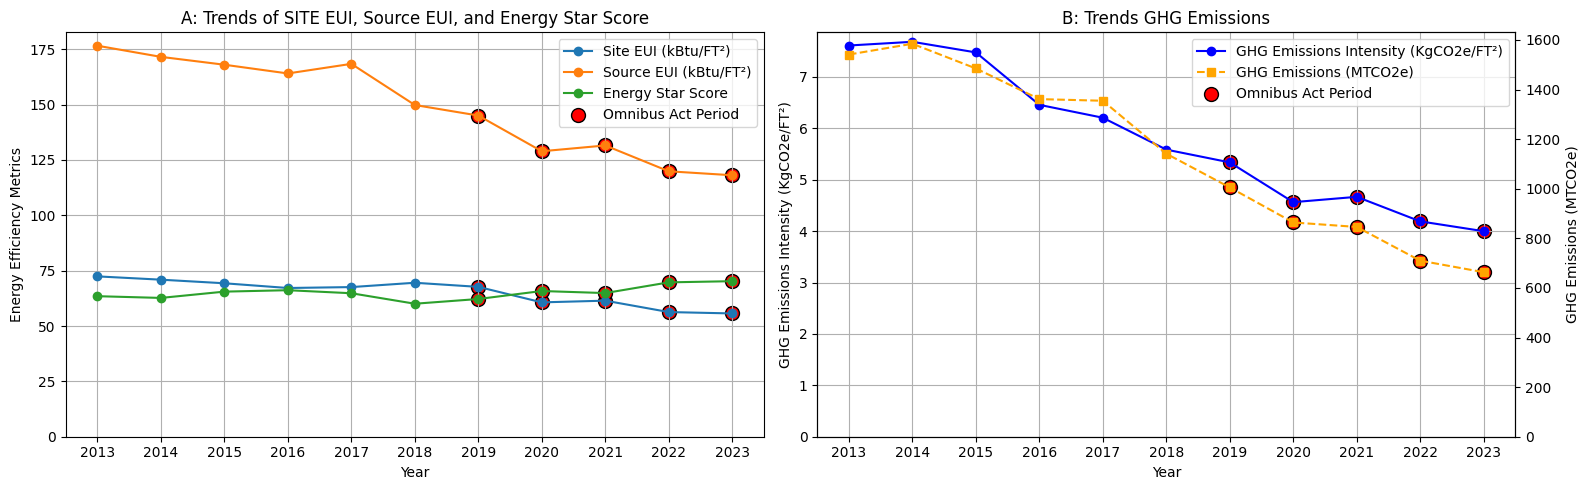

In [285]:
# Ensure the dataframe is sorted by REPORTINGYEAR
beps24_avg = beps24_avg.sort_values(by='REPORTINGYEAR')

# Create the figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ------------------- Plot 1: Energy Efficiency Metrics -------------------
columns_to_plot_1 = {
    'WeatherNormSiteEUI': 'Site EUI (kBtu/FT²)',
    'WeatherNormSourceEUI': 'Source EUI (kBtu/FT²)',
    'EnergyStar': 'Energy Star Score'
}

# Plot each variable against REPORTINGYEAR with updated labels
for col, label in columns_to_plot_1.items():
    ax1.plot(beps24_avg['REPORTINGYEAR'], beps24_avg[col], marker='o', label=label)

# Identify and mark the Omnibus Act period where Year_Dummy == 1
omnibus_act_years = beps24_avg[beps24_avg['Year_Dummy'] == 1]['REPORTINGYEAR']
omnibus_act_values_1 = beps24_avg[beps24_avg['Year_Dummy'] == 1][columns_to_plot_1.keys()]

# Mark the Omnibus Act period with red markers
for col in columns_to_plot_1.keys():
    ax1.scatter(
        omnibus_act_years, omnibus_act_values_1[col], 
        color='red', edgecolors='black', s=100, label="Omnibus Act Period" if col == 'WeatherNormSiteEUI' else ""
    )

# Ensure y-axis starts at 0
ax1.set_ylim(bottom=0)

# Formatting for Plot 1
ax1.set_xlabel("Year", color='black')
ax1.set_ylabel("Energy Efficiency Metrics", color='black')
ax1.set_title("A: Trends of SITE EUI, Source EUI, and Energy Star Score", color='black')
ax1.set_xticks(beps24_avg['REPORTINGYEAR'].unique())
ax1.legend()
ax1.grid(True)

# ------------------- Plot 2: GHG Emissions -------------------
columns_to_plot_2 = {
    'GHGEmissions_MetricTons': 'GHG Emissions (MTCO2e)',
    'GHGIntensity_KgCO2Ft': 'GHG Emissions (KgCO2e/FT²)'
}

# Plot GHG Intensity on the primary y-axis
line1, = ax2.plot(beps24_avg['REPORTINGYEAR'], beps24_avg['GHGIntensity_KgCO2Ft'], 
                   marker='o', color='blue', label='GHG Emissions Intensity (KgCO2e/FT²)')
ax2.set_xlabel("Year", color='black')
ax2.set_ylabel("GHG Emissions Intensity (KgCO2e/FT²)", color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Ensure primary y-axis starts at 0
ax2.set_ylim(bottom=0)

# Create a secondary y-axis
ax3 = ax2.twinx()
line2, = ax3.plot(beps24_avg['REPORTINGYEAR'], beps24_avg['GHGEmissions_MetricTons'], 
                   marker='s', linestyle='dashed', color='orange', label='GHG Emissions (MTCO2e)')
ax3.set_ylabel("GHG Emissions (MTCO2e)", color='black')
ax3.tick_params(axis='y', labelcolor='black')

# Ensure secondary y-axis starts at 0
ax3.set_ylim(bottom=0)

# Identify and mark the Omnibus Act period
omnibus_act_values_2_sqft = beps24_avg[beps24_avg['Year_Dummy'] == 1]['GHGIntensity_KgCO2Ft']
omnibus_act_values_2_kgco2e = beps24_avg[beps24_avg['Year_Dummy'] == 1]['GHGEmissions_MetricTons']

# Mark the Omnibus Act period with red markers
scatter1 = ax2.scatter(omnibus_act_years, omnibus_act_values_2_sqft, color='red', 
                        edgecolors='black', s=100, label="Omnibus Act Period")
scatter2 = ax3.scatter(omnibus_act_years, omnibus_act_values_2_kgco2e, color='red', 
                        edgecolors='black', s=100)

# Ensure sequential x-axis labels
ax2.set_xticks(beps24_avg['REPORTINGYEAR'].unique())

# Combine legends
lines = [line1, line2, scatter1]
labels = [line.get_label() for line in lines]
ax2.legend(lines, labels, loc='upper right')

# Formatting for Plot 2
ax2.set_title("B: Trends GHG Emissions", color='black')
ax2.grid(True)

# Adjust layout and save
plt.tight_layout()
plt.savefig("beps24_trends.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

In [ ]:
## END ##

In [ ]:
## END ##

In [ ]:
## END ##